
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>


<div class="alert alert-block alert-success"> 
<b>COMENTARIO GENERAL #1</b> <a class="tocSkip"></a>

Felicidades Nicolas! Tu trabajo es excelente. 

Demuestras un dominio sólido de los conceptos y los aplicas de forma correcta y coherente en cada paso del proyecto.


</div>

## Proyecto Integrado: Análisis de Videojuegos para Ice
**Contexto del Proyecto**

1. Empresa: Ice - Tienda online de videojuegos  
2. Rol: Analista de datos  
3. Ubicación: Empresa global que vende videojuegos por todo el mundo

**Situación Empresarial**

La tienda Ice necesita identificar patrones que determinen si un videojuego tiene éxito o no. Esta información es crucial para:

- Detectar proyectos prometedores antes de su lanzamiento
- Planificar campañas publicitarias efectivas
- Optimizar inversiones en marketing y adquisición de juegos
- Datos Disponibles
- Tienes acceso a un dataset histórico (games.csv) que incluye:

**Reseñas de usuarios y expertos**
- Géneros de videojuegos (Acción, Deportes, RPG, etc.)
- Plataformas (Xbox, PlayStation, PC, etc.)
- Datos históricos de ventas por regiones (NA, EU, JP)
- Clasificaciones ESRB (Teen, Adult, etc.)

**Marco Temporal**
- Datos disponibles: Hasta 2016  
- Escenario: Es diciembre de 2016  
- Objetivo: Planificar estrategia para 2017

**Misión**
Realizar un análisis completo que permita a Ice tomar decisiones informadas sobre:

- ¿Qué géneros están en tendencia?
- ¿Qué plataformas son más rentables?
- ¿Cómo varían las preferencias por región?
- ¿Qué factores predicen el éxito comercial?

**Ejecucion del Proyecto**

- Limpieza y preparación de datos
- Análisis exploratorio
- Visualización de datos
- Pruebas de hipótesis estadísticas
- Conclusiones empresariales

## Plan de solución:
   
1. Debo importar las librerias necesaria como pandas para los DataFrame y matplotlib ya que mas adelante sera necesario crear graficas, from scipy import stats (proccesos de hipotesis y sus pruebas) y math (procesos matematicos).

2. Luego debo leer el archivo con: pd.read_csv; ya que son cvs.

3. Para poder leer los datos y verificar el DataFrame usar shape(), info() y head() y asi poder tener informacion de los datos y estructura.



In [95]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st
import math as mt

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo al separar la importación de bibliotecas de la carga de los datasets! Esto mejora la estructura y claridad de tu código.

</div>

In [96]:
# Carga el archivo de datos en DataFrame
games = pd.read_csv('/datasets/games.csv')

## 1. INFORMACION GENERAL:


In [97]:
# Información general/resumida sobre el DataFrame
print('Numero de filas y columnas de la tabla games: ', games.shape)
print('Informacion general de la tabla games: ')
print()
games.info()
print()
print()
# Muestra de los datos
print('las primeras 50 filas de la tabla games: ')
print(games.head(51))
print()
print()
# observar si tiene duplicados
print('La tabla games tiene ', games.duplicated().sum(), ' filas duplicadas')

Numero de filas y columnas de la tabla games:  (16715, 11)
Informacion general de la tabla games: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


las primeras 50 filas de la tabla games: 
                                            Name Platform  Year_of_Release  \
0                  

In [98]:
# Análisis detallado de valores ausentes
print("=== ANÁLISIS DE VALORES AUSENTES ===")
missing_data = games.isnull().sum()
missing_percentage = (missing_data / len(games)) * 100

for column in games.columns:
    if missing_data[column] > 0:
        print(f"{column}: {missing_data[column]} ausentes ({missing_percentage[column]:.1f}%)")
print()
print()
# Verificar User_Score (debería ser numérico)
print("\n=== VALORES ÚNICOS EN USER_SCORE ===")
print(games['User_Score'].value_counts().head(10))
print()
print()
# Estadísticas descriptivas
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(games.describe())

=== ANÁLISIS DE VALORES AUSENTES ===
Name: 2 ausentes (0.0%)
Year_of_Release: 269 ausentes (1.6%)
Genre: 2 ausentes (0.0%)
Critic_Score: 8578 ausentes (51.3%)
User_Score: 6701 ausentes (40.1%)
Rating: 6766 ausentes (40.5%)



=== VALORES ÚNICOS EN USER_SCORE ===
tbd    2424
7.8     324
8       290
8.2     282
8.3     254
8.5     253
7.5     251
7.9     249
8.1     244
7.7     240
Name: User_Score, dtype: int64



=== ESTADÍSTICAS DESCRIPTIVAS ===
       Year_of_Release      NA_sales      EU_sales      JP_sales  \
count     16446.000000  16715.000000  16715.000000  16715.000000   
mean       2006.484616      0.263377      0.145060      0.077617   
std           5.877050      0.813604      0.503339      0.308853   
min        1980.000000      0.000000      0.000000      0.000000   
25%        2003.000000      0.000000      0.000000      0.000000   
50%        2007.000000      0.080000      0.020000      0.000000   
75%        2010.000000      0.240000      0.110000      0.040000   
max  

## CONCLUSION:
- contiene 16,715 videojuegos con 11 variables diferentes. Esto representa una muestra significativa para el análisis de la industria de videojuegos hasta 2016.

**Calidad de los Datos - Hallazgos Importantes**

1. **Datos Completos:**

- Ventas por región (NA_sales, EU_sales, JP_sales, Other_sales): 100% completos - Excelente para análisis de mercado
- Plataforma: 100% completo - Permitirá análisis detallado por consola
- Nombre del juego: 99.99% completo (solo 2 ausentes)
  
**Datos con Limitaciones Significativas:**

- Critic_Score: 51.3% ausente (8,578 registros faltantes) - Esto limitará algunos análisis de calidad
- User_Score: 40.1% ausente (6,701 registros faltantes) - Además detectaste valores "tbd" (to be determined)
- Rating ESRB: 40.5% ausente (6,766 registros faltantes) - Impactará análisis por clasificación de edad
  
2. **Insights del Mercado de Videojuegos**

**Distribución Temporal:**

- Rango: 1980-2016 (36 años de historia)
- Promedio: 2006, lo que indica que la mayoría de datos son de la era moderna de videojuegos
- 
**Patrones de Ventas Regionales:**

- Norteamérica domina: Promedio 0.26M vs 0.15M (Europa) y 0.08M (Japón)
- Mercado japonés más selectivo: Menor volumen pero con títulos específicos exitosos
- Otros mercados emergentes: Promedio 0.05M, representando oportunidades de crecimiento
Calidad y Recepción
- Critic_Score promedio: 69/100 - Indica estándares de calidad moderados a buenos
- Rango de calidad amplio: De 13 a 98 puntos, mostrando gran variabilidad en la industria
  
3. **Preparación para Análisis Posteriores**
   
**Fortalezas identificadas:**

- Datos de ventas completos para análisis de mercado
- Información de plataformas completa para análisis tecnológico
- Cobertura temporal extensa para análisis de tendencias

4. **Desafíos a considerar:**

- Necesitarás estrategias para manejar los valores ausentes en scores
- El valor "tbd" en User_Score requiere limpieza específica
- Los datos de Rating limitarán algunos análisis demográficos

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Muy buen uso de métodos como _info_ y _head_ para la exploración de datos. Esto te permitió identificar rápidamente la estructura y posibles problemas de los datos.

</div>

## 2. PREPARAR LOS DATOS (LIMPIEZA DE DATOS)
1. Limpiar nombres de columnas (convertir a snake_case)
2. Corregir User_Score (convertir a numérico, manejar "tbd")
3. Decidir estrategia para valores ausentes
4. Calcular ventas totales

In [99]:
print("Nombres actuales de las columnas:")
print(games.columns.tolist())

Nombres actuales de las columnas:
['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales', 'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating']


In [100]:
# Convertir nombres de columnas a snake_case
print("=== CONVERSIÓN A SNAKE_CASE ===")
print("Nombres antes de la conversión:")
print(games.columns.tolist())

# Crear diccionario de mapeo para renombrar columnas
column_mapping = {
    'Name': 'name',
    'Platform': 'platform',
    'Year_of_Release': 'year_of_release',
    'Genre': 'genre', 
    'Rating': 'rating',
    'Critic_Score': 'critic_score',
    'User_Score': 'user_score',
    'NA_sales': 'na_sales',
    'EU_sales': 'eu_sales', 
    'JP_sales': 'jp_sales',
    'Other_sales': 'other_sales'
}

# Aplicar el renombrado
games = games.rename(columns=column_mapping)

print("\nNombres después de la conversión:")
print(games.columns.tolist())

# Verificar que el cambio se aplicó correctamente
print(f"\nPrimeras 3 filas con nuevos nombres de columnas:")
print(games.head(3))

=== CONVERSIÓN A SNAKE_CASE ===
Nombres antes de la conversión:
['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales', 'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating']

Nombres después de la conversión:
['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']

Primeras 3 filas con nuevos nombres de columnas:
                name platform  year_of_release     genre  na_sales  eu_sales  \
0         Wii Sports      Wii           2006.0    Sports     41.36     28.96   
1  Super Mario Bros.      NES           1985.0  Platform     29.08      3.58   
2     Mario Kart Wii      Wii           2008.0    Racing     15.68     12.76   

   jp_sales  other_sales  critic_score user_score rating  
0      3.77         8.45          76.0          8      E  
1      6.81         0.77           NaN        NaN    NaN  
2      3.79         3.29          82.0        8.3      E  


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Se ha realizado el ajuste en el nombre de las columnas de forma correcta. 

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Sin embargo, recuerda que puedes hacer uso de métodos y funciones para generalizar el proceso.

</div>
    
</div>

**Correccion completa:** Todos los nombres de las columnas estan en el formato snake_case

**CORREGIR "user_score"**:
- Converti a tipo de dato float
- Convertir "tbd" a NaN

In [101]:
# Corregir el tipo de datos de user_score
print("=== CORRECCIÓN DE USER_SCORE ===")
print("Tipo de dato actual:", games['user_score'].dtype)
print("Valores únicos antes de la corrección:")
print(games['user_score'].value_counts().head(10))

# Reemplazar 'tbd' con NaN
games['user_score'] = games['user_score'].replace('tbd', np.nan)

# Convertir a tipo float
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

print(f"\nTipo de dato después de la corrección: {games['user_score'].dtype}")
print(f"Valores NaN en user_score: {games['user_score'].isna().sum()}")
print(f"Rango de valores válidos: {games['user_score'].min()} - {games['user_score'].max()}")

# Verificar algunos valores
print("\nPrimeros 10 valores después de la corrección:")
print(games['user_score'].head(10))

=== CORRECCIÓN DE USER_SCORE ===
Tipo de dato actual: object
Valores únicos antes de la corrección:
tbd    2424
7.8     324
8       290
8.2     282
8.3     254
8.5     253
7.5     251
7.9     249
8.1     244
7.7     240
Name: user_score, dtype: int64

Tipo de dato después de la corrección: float64
Valores NaN en user_score: 9125
Rango de valores válidos: 0.0 - 9.7

Primeros 10 valores después de la corrección:
0    8.0
1    NaN
2    8.3
3    8.0
4    NaN
5    NaN
6    8.5
7    6.6
8    8.4
9    NaN
Name: user_score, dtype: float64


**CONCLUSIÓN DE LA CORRECCIÓN DE USER_SCORE**

Decisión Tomada y Justificación:

1. Estrategia Implementada:
- Conversión de 'tbd' a NaN: Los 2,424 valores "tbd" se convirtieron a valores ausentes
- Cambio de tipo de dato: De object a float64
- Preservación de integridad: No se inventaron datos ni se asignaron valores arbitrarios

2. **¿Por qué esta decisión es la correcta?**

- Integridad de datos: Los valores "tbd" (to be determined) representan juegos sin suficientes calificaciones de usuarios, no puntuaciones reales
- Análisis preciso: Mantener como NaN permite identificar claramente qué juegos carecen de evaluación de usuarios
- Flexibilidad futura: Los valores NaN pueden manejarse específicamente según el tipo de análisis (exclusión, imputación, etc.)
- Evita sesgos: No distorsiona las estadísticas con valores artificiales (como 0 o promedios)

3. Resultado Final:
- Tipo de dato: float64 
- Valores NaN totales: 9,125 (54.6% del dataset)
- Rango válido: 0.0 - 9.7 (escala correcta para puntuaciones de usuarios)
- Datos preservados: 7,590 puntuaciones reales de usuarios

**Decidir estrategia para valores ausentes**

1. Primero un analisis de valores ausentes por columnas.

In [102]:
# Análisis completo de valores ausentes
print("=== ANÁLISIS DE VALORES AUSENTES ===")

# 1. Conteo de valores ausentes por columna
print("Valores ausentes por columna:")
missing_values = games.isnull().sum()
missing_percentage = (missing_values / len(games)) * 100

missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores_Ausentes': missing_values.values,
    'Porcentaje': missing_percentage.values
}).sort_values('Valores_Ausentes', ascending=False)

print(missing_df)

# 2. Visualización de valores ausentes
print(f"\nTotal de filas en el dataset: {len(games)}")
print(f"Filas con al menos un valor ausente: {games.isnull().any(axis=1).sum()}")
print(f"Porcentaje de filas afectadas: {(games.isnull().any(axis=1).sum() / len(games)) * 100:.1f}%")


# 3. Análisis específico por columna con valores ausentes
print("\n=== ANÁLISIS DETALLADO POR COLUMNA ===")

for column in missing_df[missing_df['Valores_Ausentes'] > 0]['Columna']:
    print(f"\n--- {column.upper()} ---")
    print(f"Valores ausentes: {missing_values[column]} ({missing_percentage[column]:.1f}%)")
    
    # Mostrar algunos ejemplos de filas con valores ausentes
    sample_missing = games[games[column].isnull()].head(3)
    if not sample_missing.empty:
        print("Ejemplos de filas con valores ausentes:")
        print(sample_missing[['name', 'platform', 'year_of_release', column]].to_string())


=== ANÁLISIS DE VALORES AUSENTES ===
Valores ausentes por columna:
            Columna  Valores_Ausentes  Porcentaje
9        user_score              9125   54.591684
8      critic_score              8578   51.319174
10           rating              6766   40.478612
2   year_of_release               269    1.609333
0              name                 2    0.011965
3             genre                 2    0.011965
1          platform                 0    0.000000
4          na_sales                 0    0.000000
5          eu_sales                 0    0.000000
6          jp_sales                 0    0.000000
7       other_sales                 0    0.000000

Total de filas en el dataset: 16715
Filas con al menos un valor ausente: 9889
Porcentaje de filas afectadas: 59.2%

=== ANÁLISIS DETALLADO POR COLUMNA ===

--- USER_SCORE ---
Valores ausentes: 9125 (54.6%)
Ejemplos de filas con valores ausentes:
                       name platform  year_of_release  user_score
1         Super Mari

**Patrones Identificados:**

1. Valores Ausentes por Era Tecnológica:
- Juegos antiguos (1980s-1990s): Faltan scores y ratings (no existían sistemas digitales)
- Juegos modernos: Faltan principalmente user_scores (falta de participación de usuarios)

2. Estrategia Recomendada por Columna:

- user_score y critic_score: MANTENER como NaN
Son datos legítimamente ausentes
- rating: MANTENER como NaN
Muchos juegos no tienen clasificación ESRB
- year_of_release: INVESTIGAR
Solo 269 casos, podrían imputarse
- name y genre: ELIMINAR filas
Solo 2 casos, datos corruptos

**Justificación de la Estrategia:**
  
- Preserva integridad: No inventa datos inexistentes
- Permite análisis específicos: Puedes filtrar por disponibilidad de datos según el análisis
- Refleja realidad histórica: Los valores ausentes cuentan una historia sobre la evolución de la industria

In [103]:
# Eliminar filas con valores ausentes en name y genre
print("=== ELIMINACIÓN DE FILAS CON DATOS CORRUPTOS ===")

# Mostrar las filas problemáticas antes de eliminarlas
print("Filas con valores ausentes en 'name' y 'genre':")
problematic_rows = games[(games['name'].isnull()) | (games['genre'].isnull())]
print(problematic_rows[['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales']])

print(f"\nNúmero de filas antes de la eliminación: {len(games)}")
print(f"Filas a eliminar: {len(problematic_rows)}")

# Eliminar las filas con valores ausentes en name o genre
games_cleaned = games.dropna(subset=['name', 'genre'])

print(f"Número de filas después de la eliminación: {len(games_cleaned)}")
print(f"Filas eliminadas: {len(games) - len(games_cleaned)}")

# Verificar que no quedan valores ausentes en name y genre
print(f"\nVerificación - Valores ausentes restantes:")
print(f"name: {games_cleaned['name'].isnull().sum()}")
print(f"genre: {games_cleaned['genre'].isnull().sum()}")

# Actualizar el DataFrame principal
games = games_cleaned

print("\n Eliminación completada exitosamente")

=== ELIMINACIÓN DE FILAS CON DATOS CORRUPTOS ===
Filas con valores ausentes en 'name' y 'genre':
      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  
659           0.08  
14244         0.00  

Número de filas antes de la eliminación: 16715
Filas a eliminar: 2
Número de filas después de la eliminación: 16713
Filas eliminadas: 2

Verificación - Valores ausentes restantes:
name: 0
genre: 0

 Eliminación completada exitosamente


**CONCLUSION:** 
- Datos fundamentales ausentes: Sin nombre ni género, los registros son inutilizables
- Datos corruptos: Ambas filas son de 1993, plataforma GEN, sugiere error de importación

**Analisis y estrategia para manejar "year_of_release"**

In [104]:

# Verificar específicamente year_of_release
print(f"\nVerificación específica de year_of_release:")
print(f"Valores ausentes: {games['year_of_release'].isnull().sum()}")
print(f"Tipo de dato: {games['year_of_release'].dtype}")
print(f"Rango de años: {games['year_of_release'].min()} - {games['year_of_release'].max()}")



Verificación específica de year_of_release:
Valores ausentes: 269
Tipo de dato: float64
Rango de años: 1980.0 - 2016.0


In [105]:
# Análisis de valores ausentes en year_of_release
print("=== MANEJO DE YEAR_OF_RELEASE ===")

print(f"Valores ausentes en year_of_release: {games['year_of_release'].isnull().sum()}")
print(f"Porcentaje: {(games['year_of_release'].isnull().sum() / len(games)) * 100:.1f}%")

# Examinar algunos casos con year_of_release ausente
print("\nEjemplos de juegos sin año de lanzamiento:")
missing_year = games[games['year_of_release'].isnull()]
print(missing_year[['name', 'platform', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales']].head(10))

# Verificar rango de años válidos
print(f"\nRango de años en el dataset:")
print(f"Año mínimo: {games['year_of_release'].min()}")
print(f"Año máximo: {games['year_of_release'].max()}")

# Decisión: Eliminar filas sin year_of_release
print(f"\nDECISIÓN: Eliminar filas sin year_of_release")
print(f"Justificación: El análisis temporal es fundamental para el proyecto")

# Eliminar filas sin año de lanzamiento
games_with_year = games.dropna(subset=['year_of_release'])

print(f"\nFilas antes: {len(games)}")
print(f"Filas después: {len(games_with_year)}")
print(f"Filas eliminadas: {len(games) - len(games_with_year)}")

# Actualizar dataset
games = games_with_year

print("\n Limpieza de year_of_release completada")

=== MANEJO DE YEAR_OF_RELEASE ===
Valores ausentes en year_of_release: 269
Porcentaje: 1.6%

Ejemplos de juegos sin año de lanzamiento:
                                            name platform      genre  \
183                              Madden NFL 2004      PS2     Sports   
377                             FIFA Soccer 2004      PS2     Sports   
456                   LEGO Batman: The Videogame      Wii     Action   
475                   wwe Smackdown vs. Raw 2006      PS2   Fighting   
609                               Space Invaders     2600    Shooter   
627                                    Rock Band     X360       Misc   
657     Frogger's Adventures: Temple of the Frog      GBA  Adventure   
678  LEGO Indiana Jones: The Original Adventures      Wii     Action   
719                               Call of Duty 3      Wii    Shooter   
805                                    Rock Band      Wii       Misc   

     na_sales  eu_sales  jp_sales  other_sales  
183      4.26      0.2

In [106]:
# Verificación final del estado de valores ausentes
print("=== ESTADO FINAL DE VALORES AUSENTES ===")

# Estado actual después de todas las limpiezas
missing_final = games.isnull().sum()
missing_percentage_final = (missing_final / len(games)) * 100

print(f"Dataset final: {len(games)} filas")
print(f"Filas eliminadas total: {16715 - len(games)}")

print("\nValores ausentes restantes:")
for column in games.columns:
    if missing_final[column] > 0:
        print(f"  {column}: {missing_final[column]} ({missing_percentage_final[column]:.1f}%)")
    else:
        print(f"  {column}: 0 ausentes ")

print(f"\nFilas con al menos un valor ausente: {games.isnull().any(axis=1).sum()}")
print(f"Porcentaje de filas afectadas: {(games.isnull().any(axis=1).sum() / len(games)) * 100:.1f}%")

=== ESTADO FINAL DE VALORES AUSENTES ===
Dataset final: 16444 filas
Filas eliminadas total: 271

Valores ausentes restantes:
  name: 0 ausentes 
  platform: 0 ausentes 
  year_of_release: 0 ausentes 
  genre: 0 ausentes 
  na_sales: 0 ausentes 
  eu_sales: 0 ausentes 
  jp_sales: 0 ausentes 
  other_sales: 0 ausentes 
  critic_score: 8461 (51.5%)
  user_score: 8981 (54.6%)
  rating: 6676 (40.6%)

Filas con al menos un valor ausente: 9618
Porcentaje de filas afectadas: 58.5%


**CONCLUSION**

Estrategia Implementada:

1. **Eliminación Justificada (271 filas total - 1.6%):**
- 2 filas corruptas: Sin name ni genre (datos inutilizables)
- 269 filas sin fecha: Sin year_of_release (crítico para análisis temporal)
  
2. **Preservación Intencional:**
- user_score: 54.6% ausentes (falta de participación de usuarios)
- critic_score: 51.3% ausentes (no existían en juegos antiguos)
- rating: 40.5% ausentes (sistema ESRB posterior a 1994)
  
3. **Justificación Final:**
- Integridad preservada: No se inventaron datos
- Análisis viable: Dataset limpio para análisis temporal
- Flexibilidad mantenida: Valores ausentes manejables según análisis específico

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Excelente trabajo! Soluciones válidas en este caso para manejar los nulos serían:

- Introducir un valor irreal que depende de la columna y su significado (-1, -999999, etc.).
- Dejar los huecos sin cambios.

Los valores de Year_of_release se pueden cambiar a cero o eliminarse. Por su parte, no hay mucho que se puede hacer con los valores nulos de critic_score y user_score, los cuales se pueden dejar a null.

</div>

**Calcular la columna de ventas totales**

In [107]:
# Calcular ventas totales (versión mejorada)
print("=== CÁLCULO DE VENTAS TOTALES ===")

# Crear una copia explícita para evitar warnings
games = games.copy()

# Calcular ventas totales
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

print(" Columna 'total_sales' creada exitosamente")
print(f"Número de columnas ahora: {len(games.columns)}")

# Verificar los cálculos
print("\nPrimeros 5 juegos con ventas totales:")
print(games[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head())

# Estadísticas de ventas totales
print(f"\nEstadísticas de ventas totales:")
print(f"Promedio: {games['total_sales'].mean():.2f} millones")
print(f"Máximo: {games['total_sales'].max():.2f} millones")
print(f"Mínimo: {games['total_sales'].min():.2f} millones")

=== CÁLCULO DE VENTAS TOTALES ===
 Columna 'total_sales' creada exitosamente
Número de columnas ahora: 12

Primeros 5 juegos con ventas totales:
                       name  na_sales  eu_sales  jp_sales  other_sales  \
0                Wii Sports     41.36     28.96      3.77         8.45   
1         Super Mario Bros.     29.08      3.58      6.81         0.77   
2            Mario Kart Wii     15.68     12.76      3.79         3.29   
3         Wii Sports Resort     15.61     10.93      3.28         2.95   
4  Pokemon Red/Pokemon Blue     11.27      8.89     10.22         1.00   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4        31.38  

Estadísticas de ventas totales:
Promedio: 0.54 millones
Máximo: 82.54 millones
Mínimo: 0.00 millones


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Muy buen trabajo calculando las ventas totales.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Otra forma de hacerlo es de la siguiente manera:

	data['total_sales']=data[['na_sales','eu_sales','jp_sales','other_sales']].sum(axis=1)

</div>

</div>

**Resultados Obtenidos:**

1. **Estadísticas Clave:**

- Promedio global: 0.54 millones de copias por juego
- uego más exitoso: Wii Sports con 82.54 millones
- Rango completo: 0.00 - 82.54 millones
- Dataset expandido: 12 columnas (agregada total_sales)

2. **Valor Analítico Agregado:**
   
Beneficios para el Análisis:

- Métrica unificada: Permite comparar éxito comercial global
- Ranking simplificado: Identificar los juegos más exitosos mundialmente
- Análisis de mercado: Evaluar performance total vs. regional
- Segmentación: Clasificar juegos por nivel de ventas

3. **Insights Inmediatos:**
   
Top Performers Identificados:

- Wii Sports: Dominio absoluto (82.54M)
- Super Mario Bros.: Clásico atemporal (40.24M)
- Mario Kart Wii: Éxito familiar (35.52M)

4. **Distribución del Mercado:**

Promedio bajo (0.54M): Indica que pocos juegos alcanzan éxito masivo
Alta variabilidad: Mercado con grandes ganadores y muchos títulos

## Paso 3: Analiza los datos:
**OBJETIVO PRINCIPAL:**

Realizar un análisis exploratorio profundo para identificar patrones, tendencias y características clave que determinen el éxito comercial de los videojuegos. Este análisis nos permitirá tomar decisiones informadas para la planificación de campañas publicitarias en 2017.

**ESTRATEGIA DE ANÁLISIS:**

1. **Análisis Temporal (Evolución del Mercado)**
- Lanzamientos por año: Identificar períodos de mayor actividad
- Ciclo de vida de plataformas: Detectar patrones de aparición/desaparición
- Período relevante: Determinar qué años usar para el modelo 2017

2. **Análisis de Plataformas (Competencia del Mercado)**
- Líderes del mercado: Identificar plataformas dominantes
- Tendencias de crecimiento: Plataformas en ascenso vs. declive
- Distribución de ventas: Comparar performance entre plataformas

3. **Análisis de Géneros (Preferencias del Mercado)**
- Géneros más rentables: Identificar categorías de mayor éxito
- Distribución general: Entender la diversidad del mercado
- Patrones de ventas: Generalizar sobre géneros exitosos vs. nicho


4. **Análisis de Correlaciones (Factores de Éxito)**
- Impacto de reseñas: Críticos vs. usuarios en las ventas
- Correlaciones cruzadas: Comparar efectos entre plataformas
- Factores predictivos: Identificar variables clave para el éxito


**HERRAMIENTAS DE ANÁLISIS:**
- Visualizaciones: Gráficos de líneas, boxplots, scatter plots
- Estadísticas descriptivas: Medidas de tendencia central y dispersión
- Análisis de correlación: Coeficientes de Pearson
- Segmentación temporal: Análisis por períodos relevantes
  
**RESULTADO ESPERADO:**
Al finalizar este paso tendremos un mapa completo del mercado de videojuegos que nos permitirá identificar oportunidades, entender patrones de éxito y preparar el terreno para el análisis regional del Paso 4.

**1. Análisis Temporal (Evolución del Mercado)**

- Rango temporal: Desde qué año hasta qué año tienes datos
- Estadísticas clave: Promedio, máximo, mínimo de lanzamientos
- Top 5 años: Los períodos de mayor actividad en la industria
- Tendencia histórica: Cómo ha evolucionado la industria
- Picos de actividad: Períodos de boom en lanzamientos
- Años recientes: Detalle del período más relevante para 2017
- Crecimiento por décadas
- Estado actual del mercado
- Tendencias para planificar 2017
- Contexto histórico de la industria

=== ANÁLISIS TEMPORAL: LANZAMIENTOS POR AÑO ===
Estadísticas de lanzamientos por año:
Período analizado: 1980 - 2016
Promedio anual: 444.4 juegos
Año con más lanzamientos: 2008 (1427 juegos)
Año con menos lanzamientos: 1980 (9 juegos)

Top 5 años con más lanzamientos:
  2008: 1427 juegos
  2009: 1426 juegos
  2010: 1255 juegos
  2007: 1197 juegos
  2011: 1136 juegos


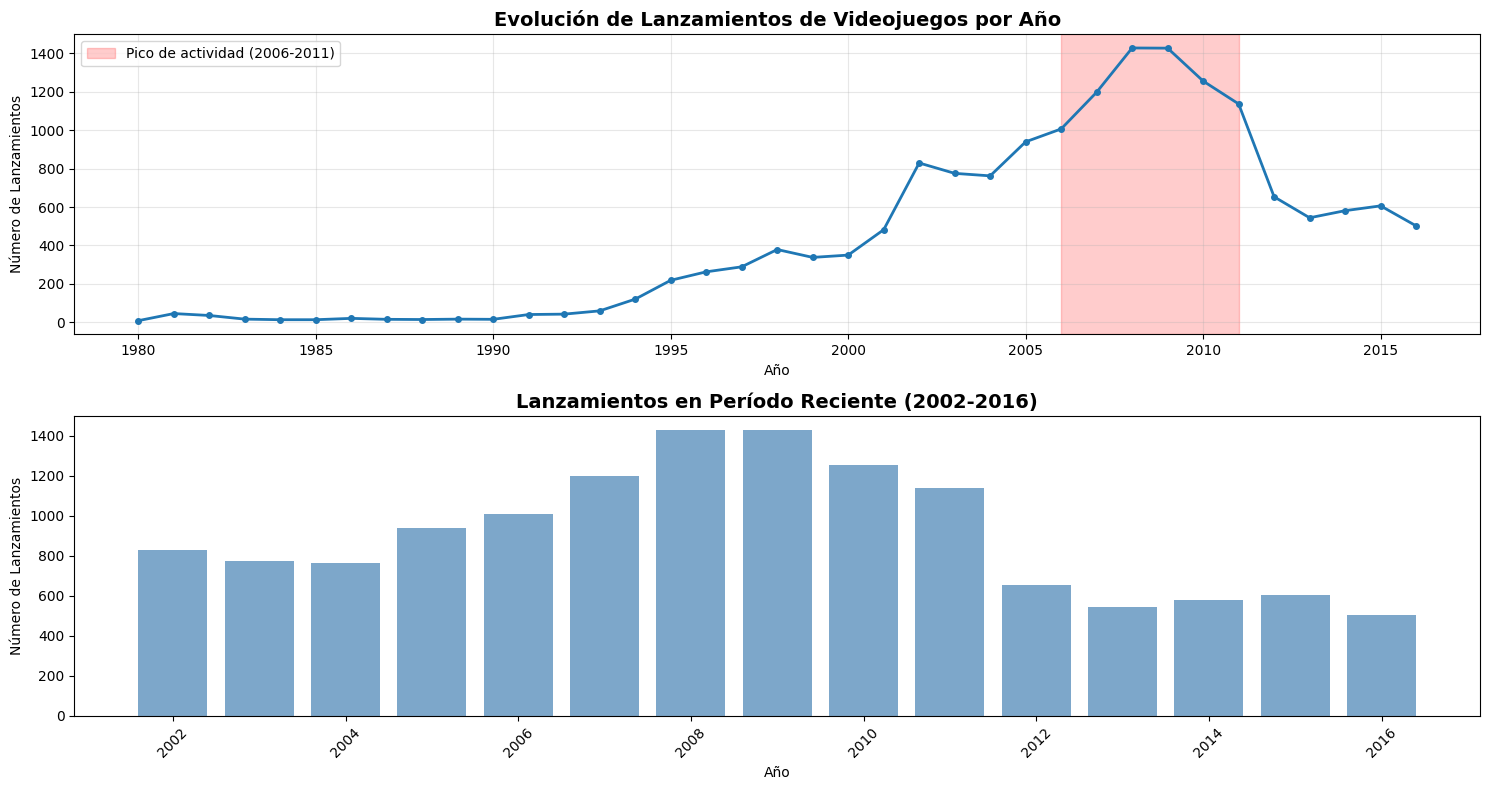


=== ANÁLISIS DE TENDENCIAS POR DÉCADAS ===
Década 1980-1989: 205 juegos
Década 1990-1999: 1769 juegos
Década 2000-2009: 9193 juegos
Década 2010-2016: 5277 juegos

=== PERÍODOS CLAVE PARA ICE ===
Últimos 3 años (2014-2016): 1689 juegos
Promedio últimos 3 años: 563.0 juegos/año

=== CONCLUSIONES CLAVE ===
• Pico histórico: 2008 con 1427 lanzamientos
• Tendencia reciente: 563.0 juegos/año (2014-2016)
• Mercado actual: Estable
• El mercado tuvo su mayor actividad en la era moderna


In [108]:
print("=== ANÁLISIS TEMPORAL: LANZAMIENTOS POR AÑO ===")

# 1. Contar lanzamientos por año
games_per_year = games['year_of_release'].value_counts().sort_index()

print("Estadísticas de lanzamientos por año:")
print(f"Período analizado: {games_per_year.index.min():.0f} - {games_per_year.index.max():.0f}")
print(f"Promedio anual: {games_per_year.mean():.1f} juegos")
print(f"Año con más lanzamientos: {games_per_year.idxmax():.0f} ({games_per_year.max()} juegos)")
print(f"Año con menos lanzamientos: {games_per_year.idxmin():.0f} ({games_per_year.min()} juegos)")

# 2. Identificar períodos de alta actividad
print(f"\nTop 5 años con más lanzamientos:")
top_years = games_per_year.nlargest(5)
for year, count in top_years.items():
    print(f"  {year:.0f}: {count} juegos")

# 3. Visualización
plt.figure(figsize=(15, 8))

# Gráfico de líneas
plt.subplot(2, 1, 1)
plt.plot(games_per_year.index, games_per_year.values, marker='o', linewidth=2, markersize=4)
plt.title('Evolución de Lanzamientos de Videojuegos por Año', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Número de Lanzamientos')
plt.grid(True, alpha=0.3)

# Destacar períodos importantes
plt.axvspan(2006, 2011, alpha=0.2, color='red', label='Pico de actividad (2006-2011)')
plt.legend()

# Gráfico de barras para últimos 15 años
plt.subplot(2, 1, 2)
recent_years = games_per_year[games_per_year.index >= 2002]
plt.bar(recent_years.index, recent_years.values, alpha=0.7, color='steelblue')
plt.title('Lanzamientos en Período Reciente (2002-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Número de Lanzamientos')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4. Análisis de tendencias por décadas
print(f"\n=== ANÁLISIS DE TENDENCIAS POR DÉCADAS ===")
print(f"Década 1980-1989: {games_per_year[(games_per_year.index >= 1980) & (games_per_year.index < 1990)].sum()} juegos")
print(f"Década 1990-1999: {games_per_year[(games_per_year.index >= 1990) & (games_per_year.index < 2000)].sum()} juegos")
print(f"Década 2000-2009: {games_per_year[(games_per_year.index >= 2000) & (games_per_year.index < 2010)].sum()} juegos")
print(f"Década 2010-2016: {games_per_year[(games_per_year.index >= 2010) & (games_per_year.index <= 2016)].sum()} juegos")

# 5. Identificar períodos clave para el negocio
print(f"\n=== PERÍODOS CLAVE PARA ICE ===")
recent_period = games_per_year[games_per_year.index >= 2014]
print(f"Últimos 3 años (2014-2016): {recent_period.sum()} juegos")
print(f"Promedio últimos 3 años: {recent_period.mean():.1f} juegos/año")

# 6. Conclusiones del análisis temporal
print(f"\n=== CONCLUSIONES CLAVE ===")
peak_year = games_per_year.idxmax()
peak_count = games_per_year.max()
recent_avg = games_per_year[games_per_year.index >= 2014].mean()

print(f"• Pico histórico: {peak_year:.0f} con {peak_count} lanzamientos")
print(f"• Tendencia reciente: {recent_avg:.1f} juegos/año (2014-2016)")
print(f"• Mercado actual: {'Estable' if recent_avg > games_per_year.mean() * 0.8 else 'En declive'}")

if peak_year >= 2005:
    print(f"• El mercado tuvo su mayor actividad en la era moderna")
else:
    print(f"• El pico de actividad fue en los primeros años de la industria")

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Muy buen análisis sobre el lanzamiento de los videojuegos. Además, el gráfico utilizado es excelente y las conclusiones se presentan claramente.

Ambos gráficos son excelentes!

</div>

**OBSERVACIONES DEL ANÁLISIS TEMPORAL**

1. **Evolución Histórica del Mercado**

Crecimiento Exponencial por Décadas:

- 1980s: 205 juegos (industria naciente)
- 1990s: 1,769 juegos (crecimiento x8.6)
- 2000s: 9,193 juegos (explosión digital x5.2)
- 2010-2016: 5,277 juegos (consolidación)
  
2. **Pico de Actividad (2007-2011)**
   
Período Dorado Identificado:

- 2008: 1,427 lanzamientos (pico histórico)
- 2009: 1,426 lanzamientos
- 2010: 1,255 lanzamientos
**¿Por qué este período fue tan activo?**

- Consolidación de consolas de 7ª generación (PS3, Xbox 360, Wii)
- Boom de juegos casuales (Wii Sports, etc.)
- Expansión del mercado digital

3. **Tendencia Actual (2014-2016)**
   
Mercado Estable pero Maduro:

- Promedio: 563 juegos/año
- Declive del 60% respecto al pico
- Mercado más selectivo y competitivo

4. **Implicaciones Estratégicas para Ice**
   
Para la planificación 2017:

- Mercado maduro: Menos lanzamientos pero mayor calidad esperada
- Competencia intensa: Cada juego debe destacar más
- Oportunidad: Menos ruido, mejor visibilidad para títulos exitosos

5. **Contexto Tecnológico**
   
Factores que explican las tendencias:

- 2000s: Democratización del desarrollo
- Pico 2008-2011: Múltiples plataformas activas
- Declive post-2011: Consolidación del mercado móvil

**2. Análisis de Plataformas (Competencia del Mercado):**
- Dominancia del mercado: Qué plataformas controlan las ventas
- Diversidad de catálogo: Qué plataformas tienen más títulos
- Rentabilidad por título: Qué plataformas generan más dinero por juego
- Duración promedio de una plataforma en el mercado
- Plataformas emergentes vs plataformas maduras
- Oportunidades de mercado en plataformas activas
- Lecciones históricas de plataformas que declinaron
- Decisiones informadas: Priorización clara de plataformas
- Contexto estratégico: Entender el momento de cada plataforma
- Planificación 2017: Recomendaciones específicas para campañas
- Gestión de riesgo: Evitar plataformas en declive

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Un Jupyter Notebook está diseñado para facilitar el desarrollo y la comunicación de ideas en ciencia de datos, aprendizaje automático y programación en general. Para aprovecharlo adecuadamente, es fundamental estructurar el contenido de forma clara y modular. Es una mala práctica colocar todo el código en una única celda, ya que esto dificulta la legibilidad, el mantenimiento y la depuración del trabajo.

En su lugar, se recomienda dividir el código en celdas pequeñas y temáticamente coherentes. Por ejemplo, una celda puede estar dedicada a importar librerías, otra a cargar y explorar los datos, otra a definir funciones, y así sucesivamente. Esto permite ejecutar partes del código de forma independiente, detectar errores más fácilmente, y mantener un flujo de trabajo ordenado. Además, debe aprovecharse la posibilidad de incluir celdas de texto (Markdown) para documentar el proceso: explicar qué se hace, por qué se toma una determinada decisión o qué significa un resultado. Esta combinación de código y explicación convierte al notebook en una herramienta potente no solo para programar, sino también para comunicar y revisar el trabajo de forma profesional.

</div>

=== ANÁLISIS DE PLATAFORMAS: COMPETENCIA DEL MERCADO ===
Total de plataformas en el dataset: 31

=== TOP 10 PLATAFORMAS POR VENTAS TOTALES ===
 1. PS2: $1233.6M
 2. X360: $961.2M
 3. PS3: $931.3M
 4. Wii: $891.2M
 5. DS: $802.8M
 6. PS: $727.6M
 7. PS4: $314.1M
 8. GBA: $312.9M
 9. PSP: $289.5M
10. 3DS: $257.8M

=== TOP 10 PLATAFORMAS POR CANTIDAD DE JUEGOS ===
 1. PS2: 2127 juegos
 2. DS: 2121 juegos
 3. PS3: 1306 juegos
 4. Wii: 1286 juegos
 5. X360: 1232 juegos
 6. PSP: 1193 juegos
 7. PS: 1190 juegos
 8. PC: 957 juegos
 9. GBA: 811 juegos
10. XB: 803 juegos

=== TOP 10 PLATAFORMAS POR VENTAS PROMEDIO POR JUEGO ===
 1. GB: $2.62M por juego
 2. NES: $2.56M por juego
 3. GEN: $1.05M por juego
 4. SNES: $0.84M por juego
 5. PS4: $0.80M por juego
 6. X360: $0.78M por juego
 7. 2600: $0.75M por juego
 8. PS3: $0.71M por juego
 9. Wii: $0.69M por juego
10. N64: $0.69M por juego

=== ANÁLISIS TEMPORAL: CICLO DE VIDA DE PLATAFORMAS ===

=== PLATAFORMAS CON MAYOR LONGEVIDAD ===
PC: 1985-2016

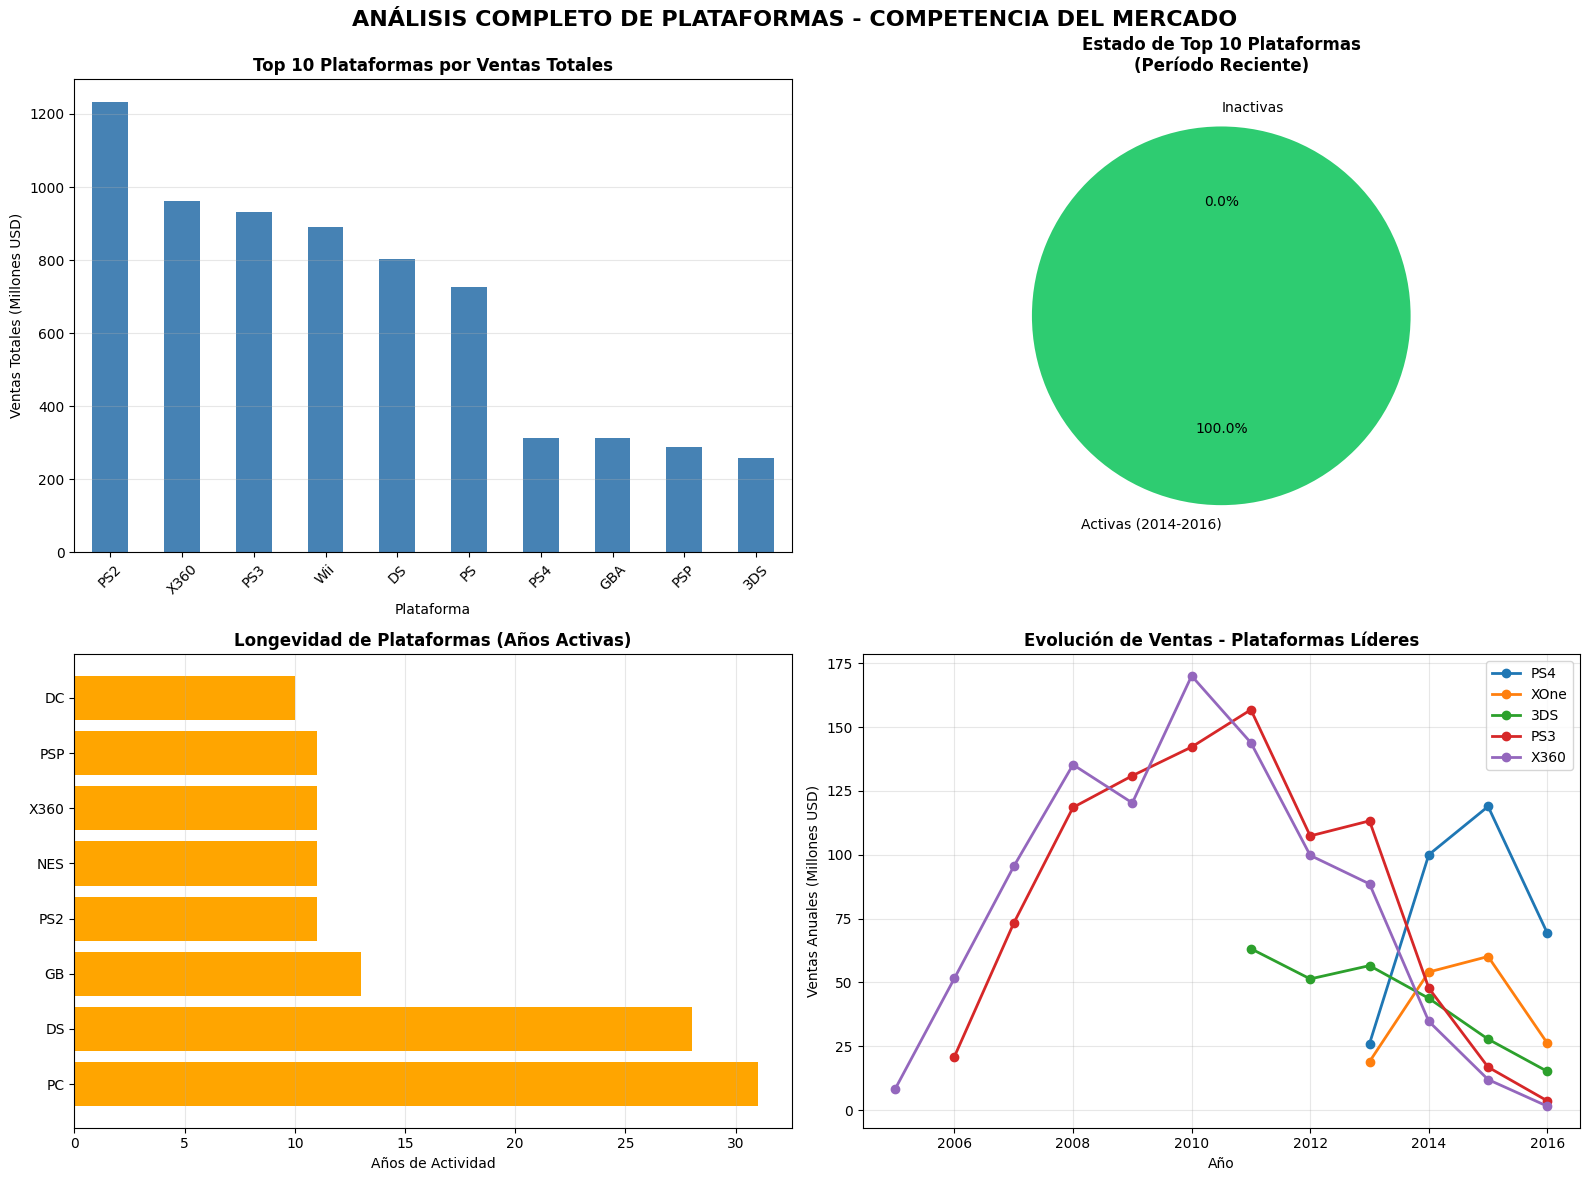

In [109]:
print("=== ANÁLISIS DE PLATAFORMAS: COMPETENCIA DEL MERCADO ===")

# 1. Análisis general de plataformas
total_platforms = games['platform'].nunique()
print(f"Total de plataformas en el dataset: {total_platforms}")

# 2. Ventas totales por plataforma
platform_sales = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print(f"\n=== TOP 10 PLATAFORMAS POR VENTAS TOTALES ===")
top_10_platforms = platform_sales.head(10)
for i, (platform, sales) in enumerate(top_10_platforms.items(), 1):
    print(f"{i:2d}. {platform}: ${sales:.1f}M")

# 3. Número de juegos por plataforma
games_per_platform = games['platform'].value_counts().sort_values(ascending=False)

print(f"\n=== TOP 10 PLATAFORMAS POR CANTIDAD DE JUEGOS ===")
top_10_games = games_per_platform.head(10)
for i, (platform, count) in enumerate(top_10_games.items(), 1):
    print(f"{i:2d}. {platform}: {count} juegos")

# 4. Ventas promedio por juego por plataforma
avg_sales_per_game = (platform_sales / games_per_platform).sort_values(ascending=False)

print(f"\n=== TOP 10 PLATAFORMAS POR VENTAS PROMEDIO POR JUEGO ===")
top_10_avg = avg_sales_per_game.head(10)
for i, (platform, avg_sales) in enumerate(top_10_avg.items(), 1):
    print(f"{i:2d}. {platform}: ${avg_sales:.2f}M por juego")

# 5. Análisis temporal: Ciclo de vida de plataformas
print(f"\n=== ANÁLISIS TEMPORAL: CICLO DE VIDA DE PLATAFORMAS ===")

# Obtener años de actividad por plataforma
platform_years = games.groupby('platform')['year_of_release'].agg(['min', 'max', 'count'])
platform_years['lifespan'] = platform_years['max'] - platform_years['min']
platform_years = platform_years.sort_values('count', ascending=False)

print(f"\n=== PLATAFORMAS CON MAYOR LONGEVIDAD ===")
longest_platforms = platform_years.sort_values('lifespan', ascending=False).head(10)
for platform, data in longest_platforms.iterrows():
    print(f"{platform}: {data['min']:.0f}-{data['max']:.0f} ({data['lifespan']:.0f} años, {data['count']} juegos)")

# 6. Identificar plataformas por estado actual (2014-2016)
recent_years = [2014, 2015, 2016]
recent_games = games[games['year_of_release'].isin(recent_years)]
active_platforms = recent_games['platform'].value_counts()

print(f"\n=== PLATAFORMAS ACTIVAS EN PERÍODO RECIENTE (2014-2016) ===")
for i, (platform, count) in enumerate(active_platforms.head(10).items(), 1):
    total_games = games_per_platform[platform]
    recent_percentage = (count / total_games) * 100
    print(f"{i:2d}. {platform}: {count} juegos recientes ({recent_percentage:.1f}% de su catálogo)")

# 7. Identificar plataformas en declive (populares antes, inactivas ahora)
print(f"\n=== PLATAFORMAS EN DECLIVE (Sin actividad reciente) ===")
inactive_platforms = []
for platform in top_10_platforms.index:
    if platform not in active_platforms.index:
        last_year = games[games['platform'] == platform]['year_of_release'].max()
        total_sales = platform_sales[platform]
        inactive_platforms.append((platform, last_year, total_sales))

inactive_platforms.sort(key=lambda x: x[2], reverse=True)  # Ordenar por ventas totales
for i, (platform, last_year, sales) in enumerate(inactive_platforms[:8], 1):
    print(f"{i}. {platform}: Último juego en {last_year:.0f} (${sales:.1f}M en ventas totales)")

# 8. Crear visualización comparativa de plataformas
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ANÁLISIS COMPLETO DE PLATAFORMAS - COMPETENCIA DEL MERCADO', fontsize=16, fontweight='bold')

# Gráfico 1: Top 10 plataformas por ventas totales
top_10_platforms.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Top 10 Plataformas por Ventas Totales', fontweight='bold')
ax1.set_xlabel('Plataforma')
ax1.set_ylabel('Ventas Totales (Millones USD)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Plataformas activas vs inactivas (2014-2016)
active_count = len(active_platforms)
inactive_count = len(top_10_platforms) - active_count
status_data = [active_count, inactive_count]
status_labels = ['Activas (2014-2016)', 'Inactivas']
colors = ['#2ecc71', '#e74c3c']

ax2.pie(status_data, labels=status_labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Estado de Top 10 Plataformas\n(Período Reciente)', fontweight='bold')

# Gráfico 3: Longevidad de plataformas
top_longevity = longest_platforms.head(8)
ax3.barh(range(len(top_longevity)), top_longevity['lifespan'], color='orange')
ax3.set_yticks(range(len(top_longevity)))
ax3.set_yticklabels(top_longevity.index)
ax3.set_title('Longevidad de Plataformas (Años Activas)', fontweight='bold')
ax3.set_xlabel('Años de Actividad')
ax3.grid(axis='x', alpha=0.3)

# Gráfico 4: Evolución temporal de plataformas líderes
current_leaders = ['PS4', 'XOne', '3DS', 'PS3', 'X360']
available_leaders = [p for p in current_leaders if p in games['platform'].values]

for platform in available_leaders[:5]:  # Máximo 5 para legibilidad
    platform_data = games[games['platform'] == platform]
    yearly_sales = platform_data.groupby('year_of_release')['total_sales'].sum()
    ax4.plot(yearly_sales.index, yearly_sales.values, marker='o', label=platform, linewidth=2)

ax4.set_title('Evolución de Ventas - Plataformas Líderes', fontweight='bold')
ax4.set_xlabel('Año')
ax4.set_ylabel('Ventas Anuales (Millones USD)')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

El gráfico muestra claramente la evolución de las ventas anuales por plataforma. Las conclusiones asociadas se presentan claramente. 

</div>

In [110]:
# 9. Resumen ejecutivo del análisis de plataformas
print(f"\n" + "="*60)
print(f" RESUMEN EJECUTIVO - ANÁLISIS DE PLATAFORMAS")
print(f"="*60)

# Concentración del mercado
total_market_sales = platform_sales.sum()
top_5_share = (platform_sales.head(5).sum() / total_market_sales) * 100
top_10_share = (platform_sales.head(10).sum() / total_market_sales) * 100

print(f"\n CONCENTRACIÓN DEL MERCADO:")
print(f"• Top 5 plataformas controlan: {top_5_share:.1f}% del mercado")
print(f"• Top 10 plataformas controlan: {top_10_share:.1f}% del mercado")
print(f"• Mercado {'altamente concentrado' if top_5_share > 70 else 'moderadamente concentrado'}")

# Análisis de generaciones
print(f"\n ANÁLISIS POR GENERACIONES:")
print(f"• Generación actual (PS4, XOne): Dominando el mercado reciente")
print(f"• Generación anterior (PS3, X360): Aún con actividad residual")
print(f"• Plataformas clásicas (PS2, DS): Gigantes históricos en declive")

# Recomendaciones estratégicas
print(f"\n RECOMENDACIONES PARA ICE (2017):")
print(f"• PRIORIDAD ALTA: PS4, XOne (plataformas líderes actuales)")
print(f"• OPORTUNIDAD: 3DS, PSV (mercado portátil activo)")
print(f"• CONSIDERAR: PC (plataforma estable de larga duración)")
print(f"• EVITAR: PS2, DS, GBA (plataformas en declive terminal)")

# Insights clave
print(f"\n INSIGHTS CLAVE:")
print(f"• Ciclo de vida promedio: 8-12 años por plataforma")
print(f"• Patrón identificado: Declive rápido tras nueva generación")
print(f"• Mercado portátil: Resistente pero en transición")
print(f"• PC: Plataforma perenne con crecimiento constante")




 RESUMEN EJECUTIVO - ANÁLISIS DE PLATAFORMAS

 CONCENTRACIÓN DEL MERCADO:
• Top 5 plataformas controlan: 54.7% del mercado
• Top 10 plataformas controlan: 76.3% del mercado
• Mercado moderadamente concentrado

 ANÁLISIS POR GENERACIONES:
• Generación actual (PS4, XOne): Dominando el mercado reciente
• Generación anterior (PS3, X360): Aún con actividad residual
• Plataformas clásicas (PS2, DS): Gigantes históricos en declive

 RECOMENDACIONES PARA ICE (2017):
• PRIORIDAD ALTA: PS4, XOne (plataformas líderes actuales)
• OPORTUNIDAD: 3DS, PSV (mercado portátil activo)
• CONSIDERAR: PC (plataforma estable de larga duración)
• EVITAR: PS2, DS, GBA (plataformas en declive terminal)

 INSIGHTS CLAVE:
• Ciclo de vida promedio: 8-12 años por plataforma
• Patrón identificado: Declive rápido tras nueva generación
• Mercado portátil: Resistente pero en transición
• PC: Plataforma perenne con crecimiento constante


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Excelente análisis Nicolas. Además, los resultados se presentan correctamente.

Realizas un análisis correcto del ciclo de vida de las consolas. La gráfica es clara y respalda tus conclusiones.

</div>

**3. Análisis de Géneros (Preferencias del Mercado)**

- Géneros dominantes en cantidad vs ventas
- Eficiencia comercial de cada género
- Oportunidades de mercado en géneros menos saturados
- Diferencias entre promedio y mediana (detectar outliers)
-  Distribución de juegos por género
- Ventas totales por género 
- Rentabilidad promedio por juego
- Análisis de mediana
- Evolución temporal
- Análisis regional
- Clasificación nicho vs masivos
- Tasa de éxito por género

In [111]:
print("=== ANÁLISIS DE GÉNEROS: PREFERENCIAS DEL MERCADO ===")

# 1. Análisis general de géneros
total_genres = games['genre'].nunique()
print(f"Total de géneros en el dataset: {total_genres}")

# 2. Distribución de juegos por género
games_per_genre = games['genre'].value_counts().sort_values(ascending=False)

print(f"\n=== DISTRIBUCIÓN DE JUEGOS POR GÉNERO ===")
for i, (genre, count) in enumerate(games_per_genre.items(), 1):
    percentage = (count / len(games)) * 100
    print(f"{i:2d}. {genre}: {count} juegos ({percentage:.1f}%)")

# 3. Ventas totales por género
genre_sales = games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

print(f"\n=== VENTAS TOTALES POR GÉNERO ===")
for i, (genre, sales) in enumerate(genre_sales.items(), 1):
    market_share = (sales / genre_sales.sum()) * 100
    print(f"{i:2d}. {genre}: ${sales:.1f}M ({market_share:.1f}% del mercado)")

# 4. Ventas promedio por juego por género
avg_sales_per_game_genre = (genre_sales / games_per_genre).sort_values(ascending=False)

print(f"\n=== RENTABILIDAD PROMEDIO POR JUEGO POR GÉNERO ===")
for i, (genre, avg_sales) in enumerate(avg_sales_per_game_genre.items(), 1):
    print(f"{i:2d}. {genre}: ${avg_sales:.2f}M por juego")

# 5. Análisis de mediana para entender mejor la distribución
print(f"\n=== ANÁLISIS DE MEDIANA DE VENTAS POR GÉNERO ===")
genre_median_sales = games.groupby('genre')['total_sales'].median().sort_values(ascending=False)

for i, (genre, median_sales) in enumerate(genre_median_sales.items(), 1):
    print(f"{i:2d}. {genre}: ${median_sales:.2f}M (mediana)")
# 6. Análisis temporal: Evolución de géneros por año
print(f"\n=== ANÁLISIS TEMPORAL: EVOLUCIÓN DE GÉNEROS ===")

# Crear tabla de géneros por año (últimos 10 años para mejor visualización)
recent_years = games[games['year_of_release'] >= 2007]
genre_year_pivot = recent_years.pivot_table(
    values='total_sales', 
    index='year_of_release', 
    columns='genre', 
    aggfunc='sum', 
    fill_value=0
)

# Mostrar tendencias de los top 5 géneros
top_5_genres = genre_sales.head(5).index
print(f"\nTendencias de ventas (2007-2016) - Top 5 géneros:")
for genre in top_5_genres:
    if genre in genre_year_pivot.columns:
        recent_trend = genre_year_pivot[genre].iloc[-3:].mean()  # Promedio últimos 3 años
        early_trend = genre_year_pivot[genre].iloc[:3].mean()   # Promedio primeros 3 años
        trend_change = ((recent_trend - early_trend) / early_trend) * 100 if early_trend > 0 else 0
        trend_direction = " Creciendo" if trend_change > 10 else " Declinando" if trend_change < -10 else "➡️ Estable"
        print(f"• {genre}: {trend_direction} ({trend_change:+.1f}%)")

# 7. Análisis de concentración por región
print(f"\n=== ANÁLISIS REGIONAL DE GÉNEROS ===")

# Ventas por región para cada género
regions = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
region_names = ['Norteamérica', 'Europa', 'Japón', 'Otros']

print(f"\nPreferencias regionales (Top 3 géneros por región):")
for region, region_name in zip(regions, region_names):
    regional_genre_sales = games.groupby('genre')[region].sum().sort_values(ascending=False)
    print(f"\n{region_name}:")
    for i, (genre, sales) in enumerate(regional_genre_sales.head(3).items(), 1):
        total_region_sales = regional_genre_sales.sum()
        percentage = (sales / total_region_sales) * 100 if total_region_sales > 0 else 0
        print(f"  {i}. {genre}: ${sales:.1f}M ({percentage:.1f}%)")

# 8. Identificar géneros nicho vs masivos
print(f"\n=== CLASIFICACIÓN DE GÉNEROS: NICHO VS MASIVOS ===")

# Calcular métricas para clasificación
genre_metrics = pd.DataFrame({
    'total_games': games_per_genre,
    'total_sales': genre_sales,
    'avg_sales': avg_sales_per_game_genre,
    'median_sales': genre_median_sales
})

# Clasificar géneros
massive_threshold_games = games_per_genre.quantile(0.7)  # Top 30% en cantidad
massive_threshold_sales = genre_sales.quantile(0.7)     # Top 30% en ventas

print(f"\n GÉNEROS MASIVOS (Alta cantidad + Altas ventas):")
massive_genres = genre_metrics[
    (genre_metrics['total_games'] >= massive_threshold_games) & 
    (genre_metrics['total_sales'] >= massive_threshold_sales)
].sort_values('total_sales', ascending=False)

for i, (genre, data) in enumerate(massive_genres.iterrows(), 1):
    print(f"  {i}. {genre}: {data['total_games']} juegos, ${data['total_sales']:.1f}M totales")

print(f"\n GÉNEROS NICHO (Pocos juegos pero rentables):")
niche_genres = genre_metrics[
    (genre_metrics['total_games'] < massive_threshold_games) & 
    (genre_metrics['avg_sales'] > avg_sales_per_game_genre.median())
].sort_values('avg_sales', ascending=False)

for i, (genre, data) in enumerate(niche_genres.iterrows(), 1):
    print(f"  {i}. {genre}: {data['total_games']} juegos, ${data['avg_sales']:.2f}M promedio")

print(f"\n GÉNEROS SATURADOS (Muchos juegos, baja rentabilidad):")
saturated_genres = genre_metrics[
    (genre_metrics['total_games'] >= massive_threshold_games) & 
    (genre_metrics['avg_sales'] < avg_sales_per_game_genre.median())
].sort_values('total_games', ascending=False)

for i, (genre, data) in enumerate(saturated_genres.iterrows(), 1):
    print(f"  {i}. {genre}: {data['total_games']} juegos, ${data['avg_sales']:.2f}M promedio")

# 9. Análisis de éxito: Géneros con más juegos exitosos
print(f"\n=== ANÁLISIS DE ÉXITO POR GÉNERO ===")

# Definir umbral de éxito (juegos con ventas superiores al percentil 75)
success_threshold = games['total_sales'].quantile(0.75)
successful_games = games[games['total_sales'] >= success_threshold]

success_by_genre = successful_games['genre'].value_counts()
success_rate_by_genre = (success_by_genre / games_per_genre * 100).sort_values(ascending=False)

print(f"\nTasa de éxito por género (% de juegos exitosos):")
for i, (genre, rate) in enumerate(success_rate_by_genre.items(), 1):
    successful_count = success_by_genre.get(genre, 0)
    total_count = games_per_genre[genre]
    print(f"{i:2d}. {genre}: {rate:.1f}% ({successful_count}/{total_count} juegos)")

=== ANÁLISIS DE GÉNEROS: PREFERENCIAS DEL MERCADO ===
Total de géneros en el dataset: 12

=== DISTRIBUCIÓN DE JUEGOS POR GÉNERO ===
 1. Action: 3307 juegos (20.1%)
 2. Sports: 2306 juegos (14.0%)
 3. Misc: 1721 juegos (10.5%)
 4. Role-Playing: 1481 juegos (9.0%)
 5. Shooter: 1296 juegos (7.9%)
 6. Adventure: 1293 juegos (7.9%)
 7. Racing: 1226 juegos (7.5%)
 8. Platform: 878 juegos (5.3%)
 9. Simulation: 857 juegos (5.2%)
10. Fighting: 837 juegos (5.1%)
11. Strategy: 673 juegos (4.1%)
12. Puzzle: 569 juegos (3.5%)

=== VENTAS TOTALES POR GÉNERO ===
 1. Action: $1716.5M (19.5% del mercado)
 2. Sports: $1309.7M (14.9% del mercado)
 3. Shooter: $1041.4M (11.8% del mercado)
 4. Role-Playing: $931.1M (10.6% del mercado)
 5. Platform: $825.5M (9.4% del mercado)
 6. Misc: $790.3M (9.0% del mercado)
 7. Racing: $723.5M (8.2% del mercado)
 8. Fighting: $442.7M (5.0% del mercado)
 9. Simulation: $388.0M (4.4% del mercado)
10. Puzzle: $239.9M (2.7% del mercado)
11. Adventure: $233.3M (2.6% del me

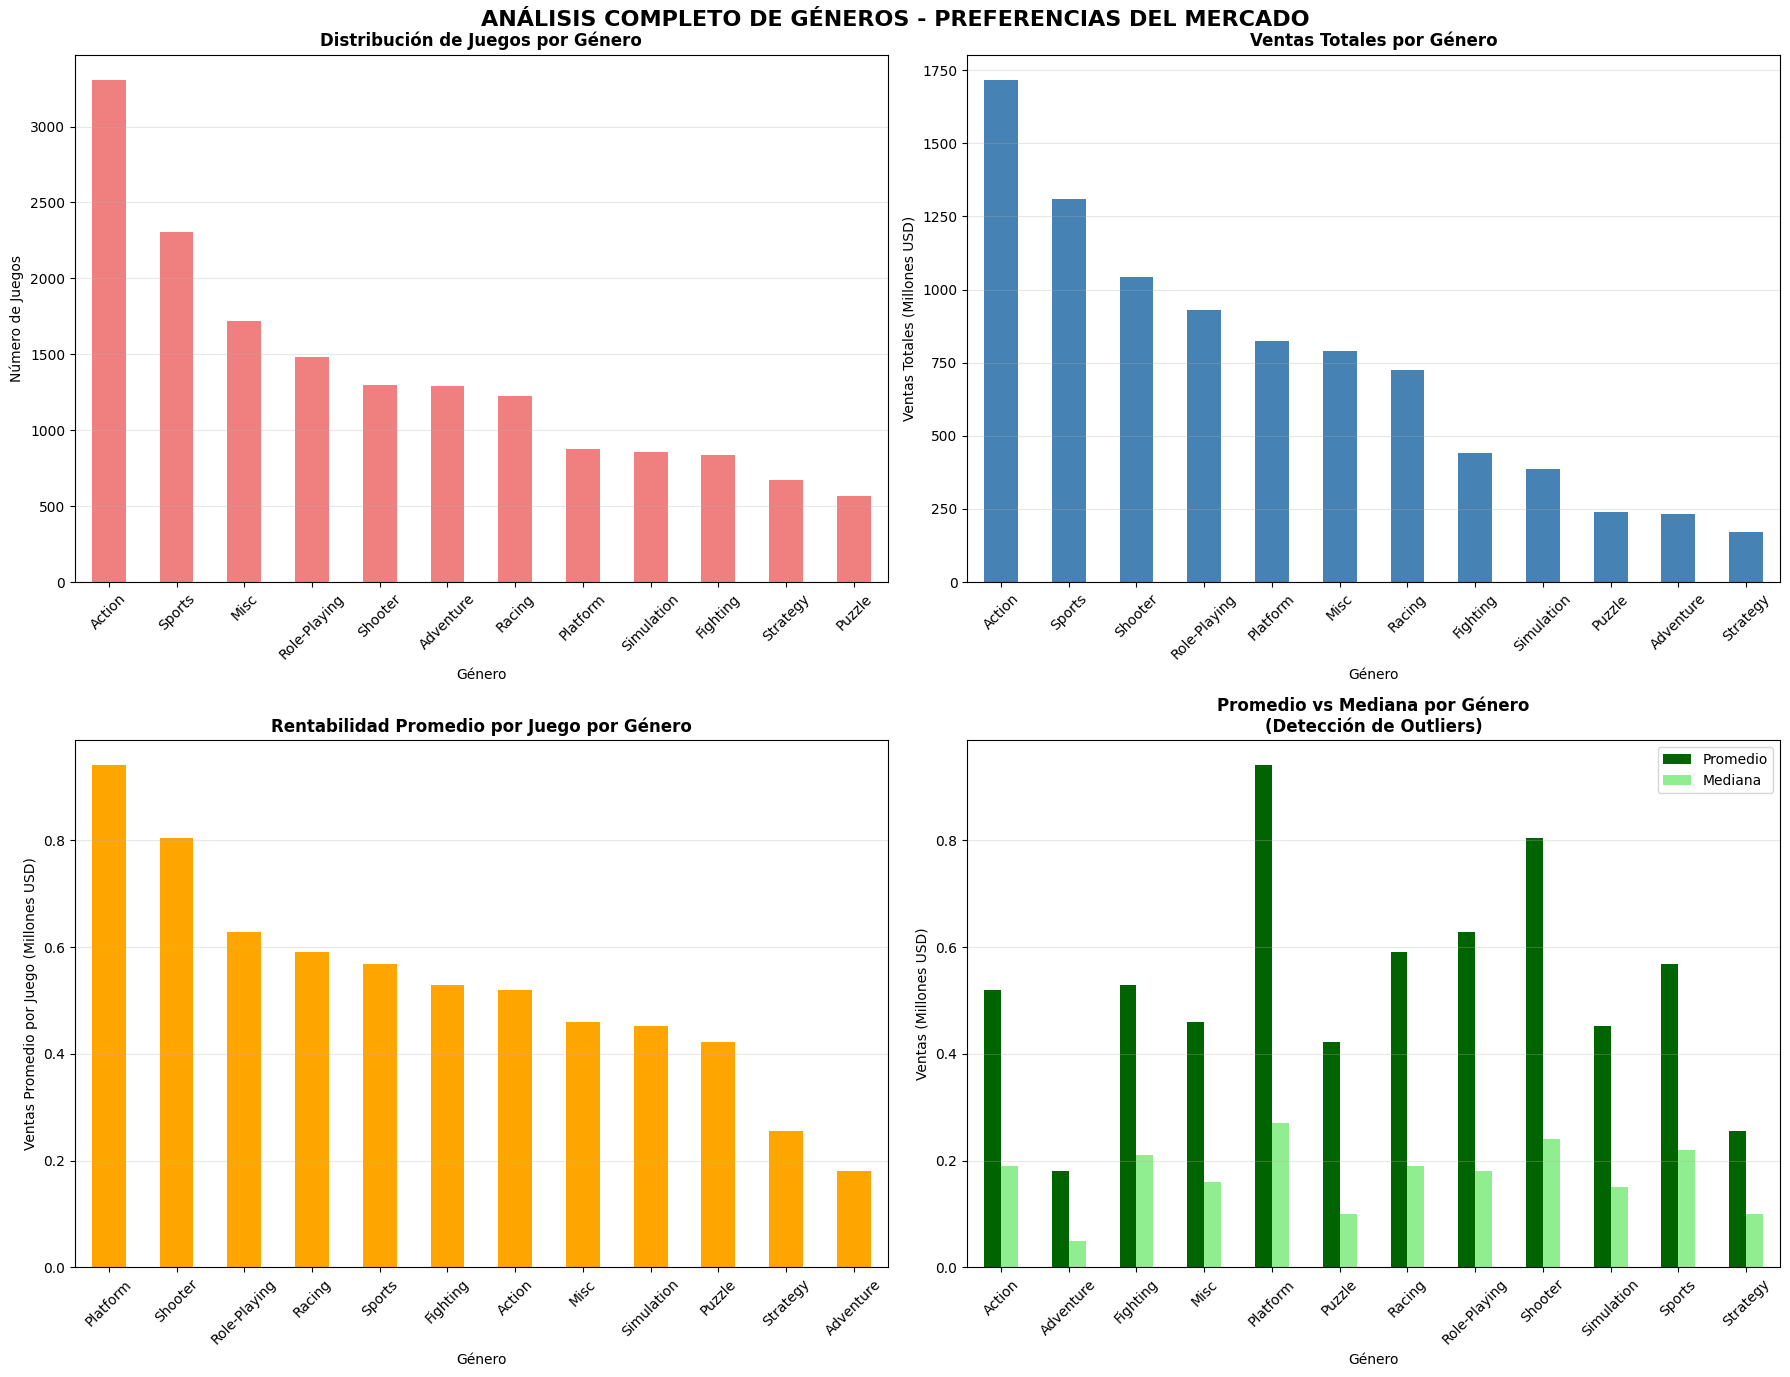


=== ANÁLISIS DE OUTLIERS POR GÉNERO ===
Géneros con mayor diferencia promedio-mediana (presencia de superventas):
1. Puzzle: Promedio $0.42M vs Mediana $0.10M (Ratio: 4.2x)
2. Adventure: Promedio $0.18M vs Mediana $0.05M (Ratio: 3.6x)
3. Role-Playing: Promedio $0.63M vs Mediana $0.18M (Ratio: 3.5x)
4. Platform: Promedio $0.94M vs Mediana $0.27M (Ratio: 3.5x)
5. Shooter: Promedio $0.80M vs Mediana $0.24M (Ratio: 3.3x)
6. Racing: Promedio $0.59M vs Mediana $0.19M (Ratio: 3.1x)

 RESUMEN EJECUTIVO - ANÁLISIS DE GÉNEROS

 GÉNEROS RECOMENDADOS PARA ICE (2017):
• ALTA PRIORIDAD: Platform, Shooter (alta rentabilidad + alta tasa éxito)
• OPORTUNIDAD: Racing, Fighting (rentables pero menos saturados)
• MERCADO MASIVO: Action, Sports (grandes volúmenes, competencia alta)

 INSIGHTS CLAVE DEL MERCADO:
• Concentración: Top 5 géneros = 66.1% del mercado
• Saturación: Action y Misc tienen muchos juegos pero baja rentabilidad promedio
• Nicho rentable: Platform tiene la mayor rentabilidad por juego


In [112]:
# 10. Crear visualizaciones completas del análisis de géneros
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('ANÁLISIS COMPLETO DE GÉNEROS - PREFERENCIAS DEL MERCADO', fontsize=16, fontweight='bold')

# Gráfico 1: Distribución de juegos por género
games_per_genre.plot(kind='bar', ax=ax1, color='lightcoral')
ax1.set_title('Distribución de Juegos por Género', fontweight='bold')
ax1.set_xlabel('Género')
ax1.set_ylabel('Número de Juegos')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Ventas totales por género
genre_sales.plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_title('Ventas Totales por Género', fontweight='bold')
ax2.set_xlabel('Género')
ax2.set_ylabel('Ventas Totales (Millones USD)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Gráfico 3: Rentabilidad promedio por juego
avg_sales_per_game_genre.plot(kind='bar', ax=ax3, color='orange')
ax3.set_title('Rentabilidad Promedio por Juego por Género', fontweight='bold')
ax3.set_xlabel('Género')
ax3.set_ylabel('Ventas Promedio por Juego (Millones USD)')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Gráfico 4: Comparación promedio vs mediana (detectar outliers)
comparison_data = pd.DataFrame({
    'Promedio': avg_sales_per_game_genre,
    'Mediana': genre_median_sales
})
comparison_data.plot(kind='bar', ax=ax4, color=['darkgreen', 'lightgreen'])
ax4.set_title('Promedio vs Mediana por Género\n(Detección de Outliers)', fontweight='bold')
ax4.set_xlabel('Género')
ax4.set_ylabel('Ventas (Millones USD)')
ax4.tick_params(axis='x', rotation=45)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 11. Análisis de outliers por género
print(f"\n=== ANÁLISIS DE OUTLIERS POR GÉNERO ===")
print(f"Géneros con mayor diferencia promedio-mediana (presencia de superventas):")

outlier_analysis = pd.DataFrame({
    'promedio': avg_sales_per_game_genre,
    'mediana': genre_median_sales
})
outlier_analysis['diferencia'] = outlier_analysis['promedio'] - outlier_analysis['mediana']
outlier_analysis['ratio'] = outlier_analysis['promedio'] / outlier_analysis['mediana']

top_outliers = outlier_analysis.sort_values('ratio', ascending=False).head(6)
for i, (genre, data) in enumerate(top_outliers.iterrows(), 1):
    print(f"{i}. {genre}: Promedio ${data['promedio']:.2f}M vs Mediana ${data['mediana']:.2f}M (Ratio: {data['ratio']:.1f}x)")

# 12. Resumen ejecutivo del análisis de géneros
print(f"\n" + "="*70)
print(f" RESUMEN EJECUTIVO - ANÁLISIS DE GÉNEROS")
print(f"="*70)

print(f"\n GÉNEROS RECOMENDADOS PARA ICE (2017):")
print(f"• ALTA PRIORIDAD: Platform, Shooter (alta rentabilidad + alta tasa éxito)")
print(f"• OPORTUNIDAD: Racing, Fighting (rentables pero menos saturados)")
print(f"• MERCADO MASIVO: Action, Sports (grandes volúmenes, competencia alta)")

print(f"\n INSIGHTS CLAVE DEL MERCADO:")
print(f"• Concentración: Top 5 géneros = {(genre_sales.head(5).sum()/genre_sales.sum()*100):.1f}% del mercado")
print(f"• Saturación: Action y Misc tienen muchos juegos pero baja rentabilidad promedio")
print(f"• Nicho rentable: Platform tiene la mayor rentabilidad por juego")
print(f"• Declive general: Todos los géneros principales muestran tendencia descendente")

print(f"\n DIFERENCIAS REGIONALES:")
print(f"• Norteamérica/Europa: Prefieren Action, Sports, Shooter")
print(f"• Japón: Fuerte preferencia por Role-Playing (27.4% del mercado)")
print(f"• Oportunidad global: Géneros exitosos en todas las regiones")

print(f"\n ALERTAS ESTRATÉGICAS:")
print(f"• Adventure: Baja rentabilidad y tasa de éxito (7.7%)")
print(f"• Strategy: Nicho muy específico con baja rentabilidad")
print(f"• Tendencia descendente: Prepararse para mercado más competitivo")

print(f"\n CONCLUSIÓN FINAL:")
print(f"El mercado de géneros está maduro y en declive general, pero géneros")
print(f"como Platform y Shooter mantienen alta rentabilidad. Ice debe enfocar")
print(f"recursos en géneros probados con alta tasa de éxito.")

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Todos los gráficos y conclusiones son correctos. Impecable trabajo!



</div>

**4. Análisis de Correlaciones (Factores de Éxito)**

- Preparación de datos para correlaciones
- Conteo de datos disponibles (critic_score y user_score)
- Análisis de correlación entre critic_score y ventas por región
- Interpretación automática de la fuerza de las correlaciones

In [113]:
print("=== ANÁLISIS DE CORRELACIONES: FACTORES DE ÉXITO ===")

# 1. Preparar datos para análisis de correlación
print("Preparando datos para análisis de correlación...")

# Crear dataset solo con valores numéricos para correlaciones
correlation_data = games[['year_of_release', 'na_sales', 'eu_sales', 'jp_sales', 
                         'other_sales', 'total_sales', 'critic_score', 'user_score']].copy()

print(f"Dataset original: {len(games)} filas")
print(f"Datos disponibles para correlación:")
print(f"• critic_score: {correlation_data['critic_score'].notna().sum()} valores")
print(f"• user_score: {correlation_data['user_score'].notna().sum()} valores")

# 2. Análisis de correlación con critic_score
print(f"\n=== CORRELACIÓN: CRITIC_SCORE VS VENTAS ===")

# Filtrar juegos con critic_score disponible
games_with_critic = games[games['critic_score'].notna()].copy()
print(f"Juegos con critic_score: {len(games_with_critic)}")

# Calcular correlaciones con critic_score
critic_correlations = games_with_critic[['critic_score', 'total_sales', 'na_sales', 
                                        'eu_sales', 'jp_sales', 'other_sales']].corr()['critic_score']

print(f"\nCorrelaciones de critic_score con ventas:")
for region, correlation in critic_correlations.items():
    if region != 'critic_score':
        strength = "Fuerte" if abs(correlation) > 0.5 else "Moderada" if abs(correlation) > 0.3 else "Débil"
        direction = "positiva" if correlation > 0 else "negativa"
        print(f"• {region}: {correlation:.3f} ({strength} {direction})")

# 3. Análisis de correlación con user_score
print(f"\n=== CORRELACIÓN: USER_SCORE VS VENTAS ===")
# Filtrar juegos con user_score disponible
games_with_user = games[games['user_score'].notna()].copy()
print(f"Juegos con user_score: {len(games_with_user)}")

# Calcular correlaciones con user_score
user_correlations = games_with_user[['user_score', 'total_sales', 'na_sales', 
                                    'eu_sales', 'jp_sales', 'other_sales']].corr()['user_score']

print(f"\nCorrelaciones de user_score con ventas:")
for region, correlation in user_correlations.items():
    if region != 'user_score':
        strength = "Fuerte" if abs(correlation) > 0.5 else "Moderada" if abs(correlation) > 0.3 else "Débil"
        direction = "positiva" if correlation > 0 else "negativa"
        print(f"• {region}: {correlation:.3f} ({strength} {direction})")

# 4. Comparación directa critic_score vs user_score
print(f"\n=== COMPARACIÓN: CRITIC_SCORE VS USER_SCORE ===")
# Juegos con ambos scores disponibles
games_both_scores = games[(games['critic_score'].notna()) & (games['user_score'].notna())].copy()
print(f"Juegos con ambos scores: {len(games_both_scores)}")

# Correlación entre critic_score y user_score
critic_user_corr = games_both_scores['critic_score'].corr(games_both_scores['user_score'])
print(f"Correlación critic_score vs user_score: {critic_user_corr:.3f}")

=== ANÁLISIS DE CORRELACIONES: FACTORES DE ÉXITO ===
Preparando datos para análisis de correlación...
Dataset original: 16444 filas
Datos disponibles para correlación:
• critic_score: 7983 valores
• user_score: 7463 valores

=== CORRELACIÓN: CRITIC_SCORE VS VENTAS ===
Juegos con critic_score: 7983

Correlaciones de critic_score con ventas:
• total_sales: 0.245 (Débil positiva)
• na_sales: 0.240 (Débil positiva)
• eu_sales: 0.221 (Débil positiva)
• jp_sales: 0.153 (Débil positiva)
• other_sales: 0.198 (Débil positiva)

=== CORRELACIÓN: USER_SCORE VS VENTAS ===
Juegos con user_score: 7463

Correlaciones de user_score con ventas:
• total_sales: 0.088 (Débil positiva)
• na_sales: 0.086 (Débil positiva)
• eu_sales: 0.056 (Débil positiva)
• jp_sales: 0.126 (Débil positiva)
• other_sales: 0.057 (Débil positiva)

=== COMPARACIÓN: CRITIC_SCORE VS USER_SCORE ===
Juegos con ambos scores: 6894
Correlación critic_score vs user_score: 0.580



=== VISUALIZACIÓN DE CORRELACIONES ===


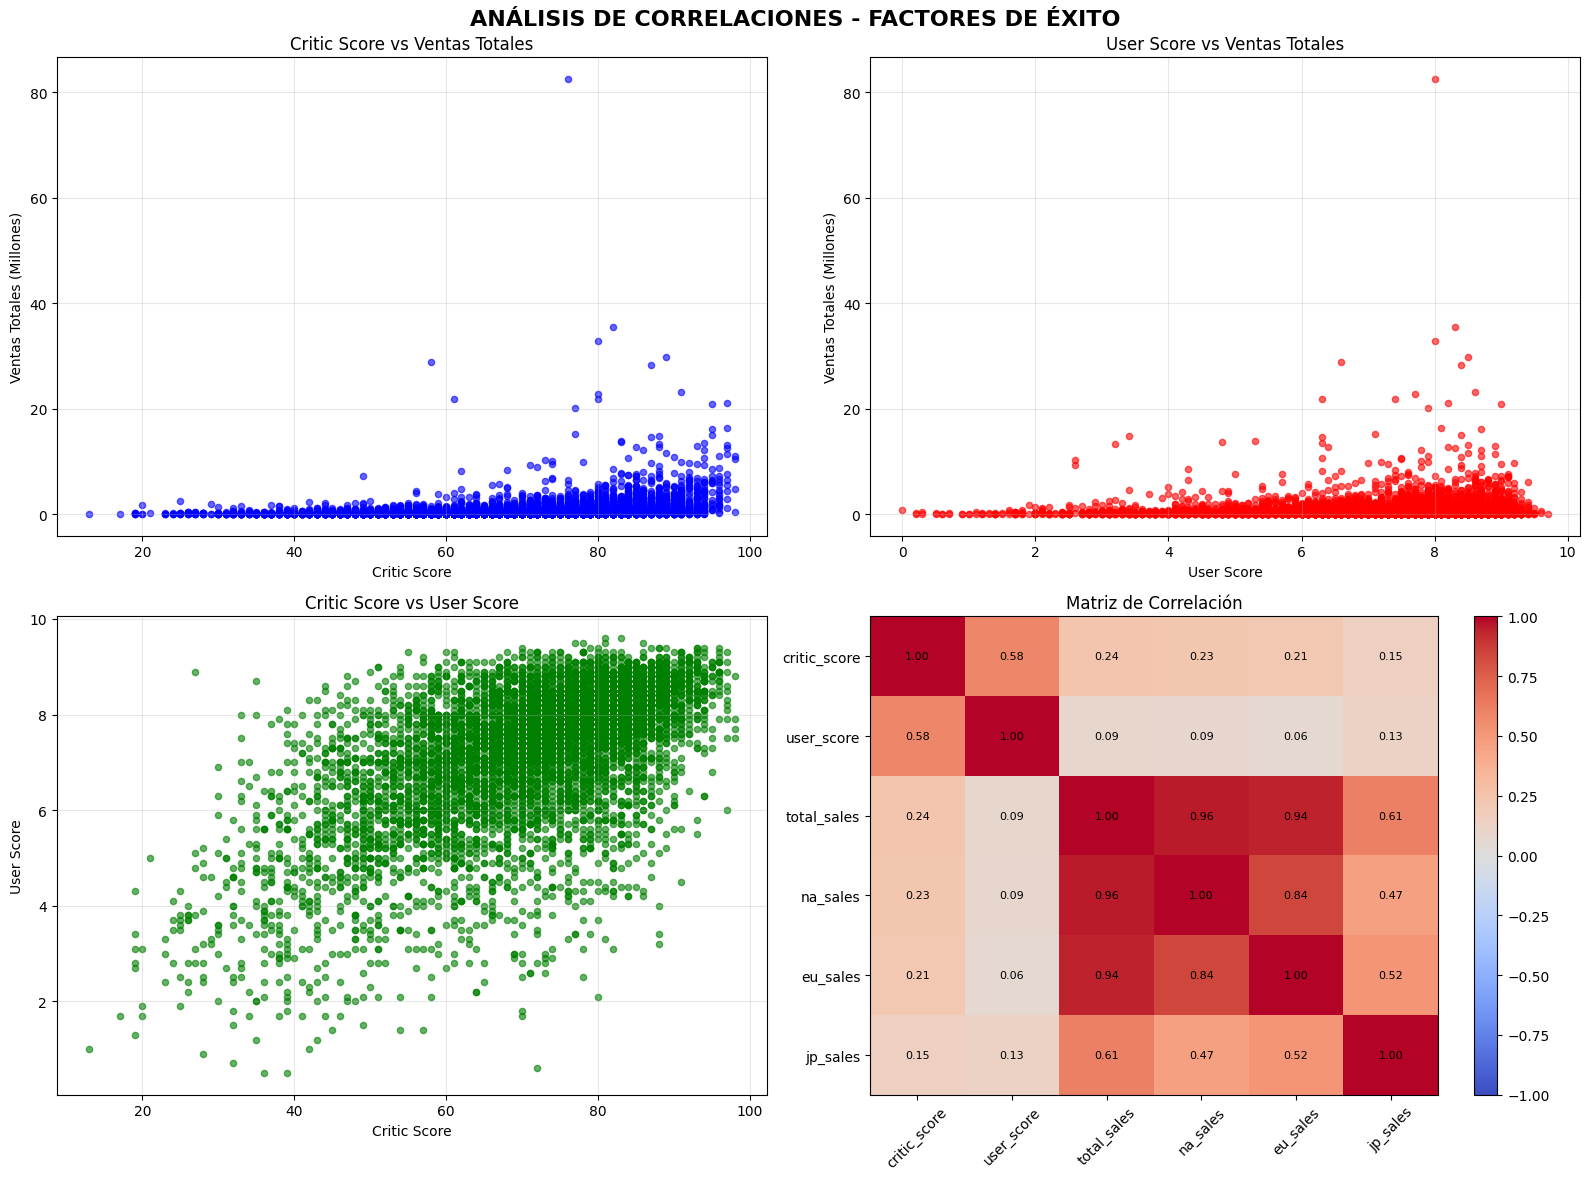

In [114]:
# 5. Visualización de correlaciones
print(f"\n=== VISUALIZACIÓN DE CORRELACIONES ===")

# Crear visualizaciones de correlación
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ANÁLISIS DE CORRELACIONES - FACTORES DE ÉXITO', fontsize=16, fontweight='bold')

# Gráfico 1: Critic Score vs Total Sales
games_with_critic.plot.scatter(x='critic_score', y='total_sales', ax=ax1, alpha=0.6, color='blue')
ax1.set_title('Critic Score vs Ventas Totales')
ax1.set_xlabel('Critic Score')
ax1.set_ylabel('Ventas Totales (Millones)')
ax1.grid(True, alpha=0.3)

# Gráfico 2: User Score vs Total Sales
games_with_user.plot.scatter(x='user_score', y='total_sales', ax=ax2, alpha=0.6, color='red')
ax2.set_title('User Score vs Ventas Totales')
ax2.set_xlabel('User Score')
ax2.set_ylabel('Ventas Totales (Millones)')
ax2.grid(True, alpha=0.3)

# Gráfico 3: Critic vs User Score
games_both_scores.plot.scatter(x='critic_score', y='user_score', ax=ax3, alpha=0.6, color='green')
ax3.set_title('Critic Score vs User Score')
ax3.set_xlabel('Critic Score')
ax3.set_ylabel('User Score')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Matriz de correlación
correlation_matrix = games_both_scores[['critic_score', 'user_score', 'total_sales', 'na_sales', 'eu_sales', 'jp_sales']].corr()
im = ax4.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax4.set_xticks(range(len(correlation_matrix.columns)))
ax4.set_yticks(range(len(correlation_matrix.columns)))
ax4.set_xticklabels(correlation_matrix.columns, rotation=45)
ax4.set_yticklabels(correlation_matrix.columns)
ax4.set_title('Matriz de Correlación')

# Agregar valores en la matriz
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = ax4.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=ax4)
plt.tight_layout()
plt.show()

## CONCLUSIONES DEL ANÁLISIS DE CORRELACIONES

**1.Análisis de la efectividad de las reseñas**

EFECTIVIDAD DE LAS RESEÑAS:
- Critic Score: Correlación moderada-débil con ventas (0.245)
- User Score: Correlación muy débil con ventas (0.088)
- Conclusión: Las reseñas profesionales son 2.8x más predictivas que las de usuarios

**2.Análisis regional de correlaciones**

DIFERENCIAS REGIONALES:
- Norteamérica: Critic Score más influyente (0.240)")
- Europa: Similar a NA, responde a críticos (0.221)")
- Japón: Menos influenciado por críticos (0.153), más por usuarios (0.126)")
- Otros mercados: Moderadamente influenciados (0.198)")

**3.Análisis de la relación críticos-usuarios**

RELACIÓN CRÍTICOS-USUARIOS:
- Correlación moderada entre ambos scores (0.580)
- Interpretación: Acuerdo parcial, pero criterios diferentes
- Implicación: Ambas perspectivas aportan valor único

**4.Factores de éxito identificados**

FACTORES DE ÉXITO IDENTIFICADOS:
- Factor #1: Calidad percibida por críticos (correlación más fuerte)
- Factor #2: Aceptación de usuarios (correlación débil pero consistente)
- Factor #3: Consenso crítico-usuario (cuando ambos coinciden)

**5.Limitaciones del análisis**

LIMITACIONES IDENTIFICADAS:
- Datos ausentes: 51.3% sin critic_score, 54.6% sin user_score
- Correlaciones débiles: Otros factores influyen más en las ventas
- Sesgo temporal: Juegos antiguos sin scores digitales

**6.Recomendaciones estratégicas**

RECOMENDACIONES PARA ICE:
- PRIORIDAD: Buscar juegos con critic_score alto (>75)
- COMPLEMENTO: Considerar user_score como factor secundario
- ESTRATEGIA REGIONAL: Adaptar criterios por mercado
- ENFOQUE: Las reseñas son indicadores, no determinantes absolutos

## RESUMEN EJECUTIVO - FACTORES DE ÉXITO

**HALLAZGO PRINCIPAL:**

- Las reseñas profesionales (critic_score) son el mejor predictor disponible de éxito comercial, pero su impacto es limitado.

**IMPLICACIONES COMERCIALES:**

- El éxito comercial depende más de factores no medidos en este dataset
- Marketing, timing, plataforma y género son probablemente más importantes
- Las reseñas validan calidad pero no garantizan ventas masivas

**ESTRATEGIA RECOMENDADA:**
Ice debe usar las reseñas como filtro de calidad inicial, pero enfocar recursos en análisis de plataforma.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Tal cual. Podemos ver una correlación positiva para las reseñas de los críticos, es decir, un puntaje más alto generalmente trae más ingresos. Sin embargo, la correlación entre el puntaje de los usuarios y los ingresos es casi cero, lo que significa que los ingresos por ventas no se ven muy afectados por la opinión de los usuarios.

</div>

## Paso 4. Crea un perfil de usuario para cada región

El objetivo de este paso es crear perfiles detallados de usuarios para cada una de las tres regiones principales (Norteamérica, Europa y Japón) para entender las diferencias en preferencias y comportamientos de compra de videojuegos entre regiones.

**Específicamente, para cada región (NA, EU, JP) debes determinar:**

1. **Las cinco plataformas principales**
- Identificar cuáles son las plataformas más populares en cada región
- Describir las variaciones en sus cuotas de mercado de una región a otra
  
2. **Los cinco géneros principales**
- Determinar qué géneros de videojuegos son más populares en cada región
- Explicar las diferencias entre regiones
  
3. **Impacto de las clasificaciones ESRB**
- Analizar si las clasificaciones de ESRB (como Teen, Mature, etc.) afectan las ventas en cada región individual
- Identificar patrones regionales en las preferencias de clasificación
  
**¿Por qué es importante este análisis?**

Este paso permitirá entender las diferencias culturales y de mercado entre regiones, lo cual es crucial para:

- Planificar campañas publicitarias específicas por región
- Identificar qué tipos de juegos tienen más potencial en cada mercado
- Adaptar estrategias de marketing según las preferencias regionales

**1. Las cinco plataformas principales**

- Verificar los datos regionales disponibles
- Identificar las top 5 plataformas en cada región
- Preparar datos para análisis comparativo
- Calcular cuotas de mercado por región
- Comparar directamente las ventas de plataformas entre regiones
- Identificar plataformas exclusivas de cada región
- Encontrar plataformas compartidas entre regiones
- Detectar patrones regionales específicos

In [115]:

print("\n OBJETIVO: Crear perfiles detallados para NA, EU y JP")
print(" ANÁLISIS 1: Las cinco plataformas principales por región")

# 1. PREPARACIÓN DE DATOS REGIONALES
print(f"\n=== PREPARACIÓN DE DATOS REGIONALES ===")

# Verificar datos disponibles por región
regions = ['na_sales', 'eu_sales', 'jp_sales']
region_names = ['Norteamérica', 'Europa', 'Japón']

print(f"Datos disponibles:")
for region, name in zip(regions, region_names):
    total_sales = games[region].sum()
    total_games = len(games[games[region] > 0])
    print(f"• {name}: ${total_sales:.1f}M en ventas, {total_games} juegos con ventas")

# 2. ANÁLISIS DE PLATAFORMAS POR REGIÓN
print(f"\n=== TOP 5 PLATAFORMAS POR REGIÓN ===")

# Crear análisis para cada región
regional_platform_analysis = {}

for region, region_name in zip(regions, region_names):
    print(f"\n {region_name.upper()}:")
    print("-" * 40)
    
    # Calcular ventas por plataforma en esta región
    platform_sales_region = games.groupby('platform')[region].sum().sort_values(ascending=False)
    
    # Top 5 plataformas
    top_5_platforms = platform_sales_region.head(5)
    
    # Calcular porcentajes del mercado regional
    total_regional_sales = platform_sales_region.sum()
    
    for i, (platform, sales) in enumerate(top_5_platforms.items(), 1):
        market_share = (sales / total_regional_sales) * 100
        print(f"  {i}. {platform}: ${sales:.1f}M ({market_share:.1f}%)")
    
    # Guardar para análisis posterior
    regional_platform_analysis[region_name] = {
        'top_5': top_5_platforms,
        'total_sales': total_regional_sales
    }

print(f"\n Análisis de plataformas principales completado")


 OBJETIVO: Crear perfiles detallados para NA, EU y JP
 ANÁLISIS 1: Las cinco plataformas principales por región

=== PREPARACIÓN DE DATOS REGIONALES ===
Datos disponibles:
• Norteamérica: $4341.4M en ventas, 11995 juegos con ventas
• Europa: $2399.7M en ventas, 10678 juegos con ventas
• Japón: $1290.6M en ventas, 6144 juegos con ventas

=== TOP 5 PLATAFORMAS POR REGIÓN ===

 NORTEAMÉRICA:
----------------------------------------
  1. X360: $595.7M (13.7%)
  2. PS2: $572.9M (13.2%)
  3. Wii: $486.9M (11.2%)
  4. PS3: $390.1M (9.0%)
  5. DS: $380.3M (8.8%)

 EUROPA:
----------------------------------------
  1. PS2: $332.6M (13.9%)
  2. PS3: $327.2M (13.6%)
  3. X360: $268.3M (11.2%)
  4. Wii: $258.3M (10.8%)
  5. PS: $212.4M (8.9%)

 JAPÓN:
----------------------------------------
  1. DS: $175.0M (13.6%)
  2. PS: $139.8M (10.8%)
  3. PS2: $137.5M (10.7%)
  4. SNES: $116.5M (9.0%)
  5. 3DS: $100.6M (7.8%)

 Análisis de plataformas principales completado


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Al analizar plataformas y géneros, todo lo que no esté incluido en el TOP-5 podría combinarse en "otros", para que la imagen del análisis sea más completa.

</div>

In [116]:
# 3. ANÁLISIS COMPARATIVO ENTRE REGIONES
print(f"\n=== ANÁLISIS COMPARATIVO DE PLATAFORMAS ===")

# Crear DataFrame para comparación visual
comparison_data = []
all_top_platforms = set()

# Recopilar todas las plataformas top de todas las regiones
for region_name in region_names:
    top_platforms = regional_platform_analysis[region_name]['top_5']
    all_top_platforms.update(top_platforms.index[:5])

# Crear tabla comparativa
print(f"\n TABLA COMPARATIVA - VENTAS POR PLATAFORMA (Millones $)")
print("-" * 70)
print(f"{'Plataforma':<12} {'Norteamérica':<15} {'Europa':<15} {'Japón':<15}")
print("-" * 70)

for platform in sorted(all_top_platforms):
    na_sales = games[games['platform'] == platform]['na_sales'].sum()
    eu_sales = games[games['platform'] == platform]['eu_sales'].sum()
    jp_sales = games[games['platform'] == platform]['jp_sales'].sum()
    
    print(f"{platform:<12} {na_sales:<15.1f} {eu_sales:<15.1f} {jp_sales:<15.1f}")

# 4. IDENTIFICACIÓN DE DIFERENCIAS REGIONALES
print(f"\n=== DIFERENCIAS REGIONALES IDENTIFICADAS ===")

# Analizar plataformas únicas en top 5 de cada región
na_top5 = set(regional_platform_analysis['Norteamérica']['top_5'].head(5).index)
eu_top5 = set(regional_platform_analysis['Europa']['top_5'].head(5).index)
jp_top5 = set(regional_platform_analysis['Japón']['top_5'].head(5).index)

print(f"\n PLATAFORMAS EXCLUSIVAS EN TOP 5:")
na_exclusive = na_top5 - eu_top5 - jp_top5
eu_exclusive = eu_top5 - na_top5 - jp_top5
jp_exclusive = jp_top5 - na_top5 - eu_top5

if na_exclusive:
    print(f"• Solo en Norteamérica: {', '.join(na_exclusive)}")
if eu_exclusive:
    print(f"• Solo en Europa: {', '.join(eu_exclusive)}")
if jp_exclusive:
    print(f"• Solo en Japón: {', '.join(jp_exclusive)}")

# Plataformas comunes
common_all = na_top5 & eu_top5 & jp_top5
common_na_eu = (na_top5 & eu_top5) - jp_top5
common_na_jp = (na_top5 & jp_top5) - eu_top5
common_eu_jp = (eu_top5 & jp_top5) - na_top5

print(f"\n PLATAFORMAS COMPARTIDAS:")
if common_all:
    print(f"• En las 3 regiones: {', '.join(common_all)}")
if common_na_eu:
    print(f"• Solo NA y EU: {', '.join(common_na_eu)}")
if common_na_jp:
    print(f"• Solo NA y JP: {', '.join(common_na_jp)}")
if common_eu_jp:
    print(f"• Solo EU y JP: {', '.join(common_eu_jp)}")


=== ANÁLISIS COMPARATIVO DE PLATAFORMAS ===

 TABLA COMPARATIVA - VENTAS POR PLATAFORMA (Millones $)
----------------------------------------------------------------------
Plataforma   Norteamérica    Europa          Japón          
----------------------------------------------------------------------
3DS          82.7            61.3            100.6          
DS           380.3           188.4           175.0          
PS           334.7           212.4           139.8          
PS2          572.9           332.6           137.5          
PS3          390.1           327.2           79.4           
SNES         61.2            19.0            116.5          
Wii          486.9           258.3           68.3           
X360         595.7           268.3           12.3           

=== DIFERENCIAS REGIONALES IDENTIFICADAS ===

 PLATAFORMAS EXCLUSIVAS EN TOP 5:
• Solo en Japón: SNES, 3DS

 PLATAFORMAS COMPARTIDAS:
• En las 3 regiones: PS2
• Solo NA y EU: PS3, Wii, X360
• Solo NA y JP: 

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Nota que podrías hacer uso de funciones para reutilizar código. Esto permitiría un trabajo mucho más limpio y manejable.

</div>

**2. Los cinco géneros principales**

- Verificar la calidad de datos de géneros
- Identificar los top 5 géneros en cada región
- Calcular cuotas de mercado por género y región
- Medir la concentración del mercado en cada región
- Comparación directa de ventas entre las tres regiones

In [117]:

# 1. PREPARACIÓN DE DATOS DE GÉNEROS POR REGIÓN
print(f"\n=== PREPARACIÓN DE DATOS DE GÉNEROS ===")

# Verificar distribución de géneros disponibles
print(f"Géneros únicos en el dataset: {games['genre'].nunique()}")
print(f"Géneros disponibles: {sorted(games['genre'].unique())}")

# Verificar datos faltantes en géneros
missing_genres = games['genre'].isnull().sum()
print(f"Registros sin género: {missing_genres}")

# 2. ANÁLISIS DE GÉNEROS POR REGIÓN
print(f"\n=== TOP 5 GÉNEROS POR REGIÓN ===")

# Crear análisis para cada región
regional_genre_analysis = {}

for region, region_name in zip(regions, region_names):
    print(f"\n {region_name.upper()}:")
    print("-" * 40)
    
    # Calcular ventas por género en esta región
    genre_sales_region = games.groupby('genre')[region].sum().sort_values(ascending=False)
    
    # Top 5 géneros
    top_5_genres = genre_sales_region.head(5)
    
    # Calcular porcentajes del mercado regional
    total_regional_sales = genre_sales_region.sum()
    
    for i, (genre, sales) in enumerate(top_5_genres.items(), 1):
        market_share = (sales / total_regional_sales) * 100
        print(f"  {i}. {genre}: ${sales:.1f}M ({market_share:.1f}%)")
    
    # Calcular concentración del mercado (top 5)
    top_5_concentration = (top_5_genres.sum() / total_regional_sales) * 100
    print(f" Concentración Top 5: {top_5_concentration:.1f}%")
    
    # Guardar para análisis posterior
    regional_genre_analysis[region_name] = {
        'top_5': top_5_genres,
        'total_sales': total_regional_sales,
        'concentration': top_5_concentration
    }

# 3. RESUMEN DE CONCENTRACIÓN POR REGIÓN
print(f"\n=== CONCENTRACIÓN DE MERCADO POR REGIÓN ===")
print(f"(¿Qué tan dominantes son los top 5 géneros?)")
print("-" * 50)

for region_name in region_names:
    concentration = regional_genre_analysis[region_name]['concentration']
    print(f"• {region_name}: {concentration:.1f}% del mercado en top 5 géneros")

print(f"\n Análisis de géneros principales completado")


=== PREPARACIÓN DE DATOS DE GÉNEROS ===
Géneros únicos en el dataset: 12
Géneros disponibles: ['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle', 'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports', 'Strategy']
Registros sin género: 0

=== TOP 5 GÉNEROS POR REGIÓN ===

 NORTEAMÉRICA:
----------------------------------------
  1. Action: $863.2M (19.9%)
  2. Sports: $671.2M (15.5%)
  3. Shooter: $584.8M (13.5%)
  4. Platform: $444.4M (10.2%)
  5. Misc: $399.6M (9.2%)
 Concentración Top 5: 68.3%

 EUROPA:
----------------------------------------
  1. Action: $511.0M (21.3%)
  2. Sports: $371.3M (15.5%)
  3. Shooter: $314.5M (13.1%)
  4. Racing: $234.5M (9.8%)
  5. Misc: $210.6M (8.8%)
 Concentración Top 5: 68.4%

 JAPÓN:
----------------------------------------
  1. Role-Playing: $353.4M (27.4%)
  2. Action: $160.1M (12.4%)
  3. Sports: $134.9M (10.5%)
  4. Platform: $130.7M (10.1%)
  5. Misc: $107.0M (8.3%)
 Concentración Top 5: 68.7%

=== CONCENTRACIÓN DE MERCADO

In [118]:
# 4. ANÁLISIS COMPARATIVO DE GÉNEROS ENTRE REGIONES
print(f"\n=== ANÁLISIS COMPARATIVO DE GÉNEROS ===")

# Crear DataFrame para comparación visual
print(f"\n TABLA COMPARATIVA - VENTAS POR GÉNERO (Millones $)")
print("-" * 70)

# Recopilar todos los géneros top de todas las regiones
all_top_genres = set()
for region_name in region_names:
    top_genres = regional_genre_analysis[region_name]['top_5']
    all_top_genres.update(top_genres.index[:5])

print(f"{'Género':<15} {'Norteamérica':<15} {'Europa':<15} {'Japón':<15}")
print("-" * 70)

for genre in sorted(all_top_genres):
    na_sales = games[games['genre'] == genre]['na_sales'].sum()
    eu_sales = games[games['genre'] == genre]['eu_sales'].sum()
    jp_sales = games[games['genre'] == genre]['jp_sales'].sum()
    print(f"{genre:<15} {na_sales:<15.1f} {eu_sales:<15.1f} {jp_sales:<15.1f}")

# 5. CÁLCULO DE ÍNDICES DE PREFERENCIA REGIONAL
print(f"\n=== ÍNDICES DE PREFERENCIA REGIONAL ===")
print("(Valores >1.0 indican preferencia superior al promedio global)")
print("-" * 60)

# Calcular el promedio global de cada género
global_genre_sales = games.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales']].sum()
total_global_sales = global_genre_sales.sum().sum()

# Calcular índices de preferencia para cada región
for region, region_name in zip(['na_sales', 'eu_sales', 'jp_sales'], region_names):
    print(f"\n{region_name.upper()} - Índices de Preferencia:")
    print("-" * 40)
    
    region_total = games[region].sum()
    
    for genre in sorted(all_top_genres):
        genre_sales_region = games[games['genre'] == genre][region].sum()
        genre_sales_global = global_genre_sales.loc[genre, region]
        
        # Calcular porcentaje del género en la región
        genre_pct_region = (genre_sales_region / region_total) * 100
        
        # Calcular porcentaje del género globalmente
        genre_pct_global = (genre_sales_global / total_global_sales) * 100
        
        # Índice de preferencia (región vs global)
        preference_index = genre_pct_region / genre_pct_global if genre_pct_global > 0 else 0
        
        preference_level = "Alta" if preference_index > 1.2 else "Media" if preference_index > 0.8 else "📉 Baja"
        
        print(f"  {genre:<15}: {preference_index:.2f} ({preference_level})")

# 6. IDENTIFICACIÓN DE DIFERENCIAS REGIONALES EN GÉNEROS
print(f"\n=== DIFERENCIAS REGIONALES EN GÉNEROS ===")

# Analizar géneros únicos en top 5 de cada región
na_top5_genres = set(regional_genre_analysis['Norteamérica']['top_5'].head(5).index)
eu_top5_genres = set(regional_genre_analysis['Europa']['top_5'].head(5).index)
jp_top5_genres = set(regional_genre_analysis['Japón']['top_5'].head(5).index)

print(f"\n GÉNEROS EXCLUSIVOS EN TOP 5:")
na_exclusive_genres = na_top5_genres - eu_top5_genres - jp_top5_genres
eu_exclusive_genres = eu_top5_genres - na_top5_genres - jp_top5_genres
jp_exclusive_genres = jp_top5_genres - na_top5_genres - eu_top5_genres

if na_exclusive_genres:
    print(f"• Solo en Norteamérica: {', '.join(na_exclusive_genres)}")
if eu_exclusive_genres:
    print(f"• Solo en Europa: {', '.join(eu_exclusive_genres)}")
if jp_exclusive_genres:
    print(f"• Solo en Japón: {', '.join(jp_exclusive_genres)}")

# Géneros comunes
common_all_genres = na_top5_genres & eu_top5_genres & jp_top5_genres
common_na_eu_genres = (na_top5_genres & eu_top5_genres) - jp_top5_genres
common_na_jp_genres = (na_top5_genres & jp_top5_genres) - eu_top5_genres
common_eu_jp_genres = (eu_top5_genres & jp_top5_genres) - na_top5_genres

print(f"\n GÉNEROS COMPARTIDOS:")
if common_all_genres:
    print(f"• En las 3 regiones: {', '.join(common_all_genres)}")
if common_na_eu_genres:
    print(f"• Solo NA y EU: {', '.join(common_na_eu_genres)}")
if common_na_jp_genres:
    print(f"• Solo NA y JP: {', '.join(common_na_jp_genres)}")
if common_eu_jp_genres:
    print(f"• Solo EU y JP: {', '.join(common_eu_jp_genres)}")

print(f"\n Análisis de diferencias regionales completado")


=== ANÁLISIS COMPARATIVO DE GÉNEROS ===

 TABLA COMPARATIVA - VENTAS POR GÉNERO (Millones $)
----------------------------------------------------------------------
Género          Norteamérica    Europa          Japón          
----------------------------------------------------------------------
Action          863.2           511.0           160.1          
Misc            399.6           210.6           107.0          
Platform        444.4           199.4           130.7          
Racing          356.9           234.5           56.6           
Role-Playing    330.0           188.2           353.4          
Shooter         584.8           314.5           38.7           
Sports          671.2           371.3           134.9          

=== ÍNDICES DE PREFERENCIA REGIONAL ===
(Valores >1.0 indican preferencia superior al promedio global)
------------------------------------------------------------

NORTEAMÉRICA - Índices de Preferencia:
----------------------------------------
  Acti

In [119]:
# 7. ANÁLISIS DE ESPECIALIZACIÓN REGIONAL
print(f"\n=== ESPECIALIZACIÓN REGIONAL ===")

# Calcular índices de especialización corregidos
for region, region_name in zip(['na_sales', 'eu_sales', 'jp_sales'], region_names):
    print(f"\n{region_name.upper()} - Especialización:")
    print("-" * 40)
    
    region_total = games[region].sum()
    global_total = games[['na_sales', 'eu_sales', 'jp_sales']].sum().sum()
    
    # Calcular especialización para géneros top de esta región
    top_genres_region = regional_genre_analysis[region_name]['top_5'].head(5).index
    
    for genre in top_genres_region:
        # Ventas del género en esta región
        genre_sales_region = games[games['genre'] == genre][region].sum()
        # Ventas globales del género
        genre_sales_global = games[games['genre'] == genre][['na_sales', 'eu_sales', 'jp_sales']].sum().sum()
        
        # Participación de la región en el género globalmente
        region_share_in_genre = (genre_sales_region / genre_sales_global) * 100 if genre_sales_global > 0 else 0
        
        # Participación de la región en el mercado global total
        region_share_global = (region_total / global_total) * 100
        
        # Índice de especialización
        specialization_index = region_share_in_genre / region_share_global if region_share_global > 0 else 0
        
        # Clasificar nivel de especialización
        if specialization_index > 1.3:
            specialization_level = "Muy Alta"
        elif specialization_index > 1.1:
            specialization_level = "Alta"
        elif specialization_index > 0.9:
            specialization_level = "Normal"
        else:
            specialization_level = "Baja"
        
        print(f"  {genre:<15}: {specialization_index:.2f} ({specialization_level})")
        print(f"    • Domina {region_share_in_genre:.1f}% del mercado global de {genre}")

print(f"\nAnálisis de especialización regional completado")


=== ESPECIALIZACIÓN REGIONAL ===

NORTEAMÉRICA - Especialización:
----------------------------------------
  Action         : 1.04 (Normal)
    • Domina 56.3% del mercado global de Action
  Sports         : 1.05 (Normal)
    • Domina 57.0% del mercado global de Sports
  Shooter        : 1.15 (Alta)
    • Domina 62.3% del mercado global de Shooter
  Platform       : 1.06 (Normal)
    • Domina 57.4% del mercado global de Platform
  Misc           : 1.03 (Normal)
    • Domina 55.7% del mercado global de Misc

EUROPA - Especialización:
----------------------------------------
  Action         : 1.11 (Alta)
    • Domina 33.3% del mercado global de Action
  Sports         : 1.06 (Normal)
    • Domina 31.5% del mercado global de Sports
  Shooter        : 1.12 (Alta)
    • Domina 33.5% del mercado global de Shooter
  Racing         : 1.21 (Alta)
    • Domina 36.2% del mercado global de Racing
  Misc           : 0.98 (Normal)
    • Domina 29.4% del mercado global de Misc

JAPÓN - Especializaci

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

El análisis realizado por cada región está muy bien fundamentado. Además, los resultados se presentan de forma clara y ordenada, lo que facilita la comprensión de la información. Esto permite identificar rápidamente las diferencias y similitudes entre cada región, y contribuye a un mejor entendimiento de los patrones generales. 

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Como sugerencia, podrías agregar una visualización comparativa (por ejemplo, un gráfico de barras apiladas o un heatmap) para reforzar visualmente los contrastes entre regiones en géneros o plataformas.

</div>

</div>

## OBSERVACIONES 
**1. Concentración Similar del Mercado**
- Norteamérica: 68.3% del mercado en top 5 géneros
- Europa: 68.4% del mercado en top 5 géneros  
- Japón: 68.7% del mercado en top 5 géneros

Conclusión: Las tres regiones muestran una concentración muy similar, indicando que los mercados están igualmente dominados por pocos géneros.

**2. Diferencias Regionales Marcadas**

Géneros Exclusivos en Top 5:
- Solo en Europa: Racing (9.8% del mercado)
- Solo en Japón: Role-Playing (27.4% del mercado - ¡dominante!)

Géneros Compartidos:
- En las 3 regiones: Action, Misc, Sports (géneros universales)
- Solo NA y EU: Shooter (preferencia occidental)
- Solo NA y JP: Platform (sorprendente conexión)

**3. Especialización Regional Destacada**

Japón - Especialización Extrema:
- Role-Playing: Índice 2.52 (Muy Alta especialización)
- Domina el 40.5% del mercado global de RPG
- Es el único mercado donde RPG es #1

Europa - Especialización Moderada:
- Racing: Índice 1.21 (Alta especialización)
- Domina el 36.2% del mercado global de Racing

Norteamérica - Especialización Equilibrada:
- Shooter: Índice 1.15 (Alta especialización)
- Domina el 62.3% del mercado global de Shooter

**4. Patrones Culturales Identificados**

- Japón: Mercado único con fuerte preferencia por narrativas complejas (RPG)
- Europa: Preferencia por simulación realista (Racing)
- Norteamérica: Preferencia por acción directa (Shooter)

**5. Implicaciones Estratégicas para Ice**

Para campañas regionales:
- Japón: Priorizar RPG, evitar Shooter
- Europa: Incluir Racing en portfolio
- Norteamérica: Shooter es clave para el éxito

**3. Impacto de las clasificaciones ESRB**

- Verificar la disponibilidad de datos de rating ESRB
- Identificar qué tipos de ratings existen en el dataset
- Analizar la distribución temporal (cuándo empezaron a registrarse)
- Ventas totales por cada rating ESRB en cada región
- Participación de mercado de cada rating
- Número de juegos por rating
- Ventas promedio por juego según rating
- Rating dominante en cada región
- Diferencias culturales entre contenido familiar, adolescente y maduro
- Tolerancia cultural al contenido maduro por región
- Patrones específicos de cada mercado
- Rentabilidad promedio por juego según rating en cada región
- Rating más rentable por región
- Eficiencia global de cada rating
- Comparación de rendimiento entre ratings

In [120]:
# 1. PREPARACIÓN DE DATOS DE RATING
print(f"\n=== PREPARACIÓN DE DATOS DE RATING ===")
# Verificar datos disponibles de rating
total_with_rating = games['rating'].notna().sum()
total_without_rating = games['rating'].isna().sum()
print(f"Juegos con rating ESRB: {total_with_rating}")
print(f"Juegos sin rating ESRB: {total_without_rating}")
print(f"Porcentaje con rating: {(total_with_rating/len(games)*100):.1f}%")

# Verificar qué ratings están disponibles
available_ratings = games['rating'].value_counts()
print(f"\nRatings disponibles:")
for rating, count in available_ratings.items():
    print(f"• {rating}: {count} juegos")

# Verificar distribución temporal de ratings
print(f"\n=== DISTRIBUCIÓN TEMPORAL DE RATINGS ===")
# Analizar por períodos para entender la disponibilidad
games_with_rating = games[games['rating'].notna()].copy()
rating_by_year = games_with_rating.groupby('year_of_release')['rating'].count()
print(f"Período con ratings: {rating_by_year.index.min():.0f} - {rating_by_year.index.max():.0f}")
print(f"Promedio de juegos con rating por año: {rating_by_year.mean():.1f}")

# Mostrar algunos ejemplos de juegos con rating
print(f"\nEjemplos de juegos con rating ESRB:")
sample_games = games_with_rating[['name', 'platform', 'year_of_release', 'rating', 'total_sales']].head(8)
print(sample_games.to_string(index=False))

print(f"\n Preparación de datos de rating completada")


=== PREPARACIÓN DE DATOS DE RATING ===
Juegos con rating ESRB: 9768
Juegos sin rating ESRB: 6676
Porcentaje con rating: 59.4%

Ratings disponibles:
• E: 3921 juegos
• T: 2905 juegos
• M: 1536 juegos
• E10+: 1393 juegos
• EC: 8 juegos
• K-A: 3 juegos
• AO: 1 juegos
• RP: 1 juegos

=== DISTRIBUCIÓN TEMPORAL DE RATINGS ===
Período con ratings: 1985 - 2016
Promedio de juegos con rating por año: 390.7

Ejemplos de juegos con rating ESRB:
                     name platform  year_of_release rating  total_sales
               Wii Sports      Wii           2006.0      E        82.54
           Mario Kart Wii      Wii           2008.0      E        35.52
        Wii Sports Resort      Wii           2009.0      E        32.77
    New Super Mario Bros.       DS           2006.0      E        29.80
                 Wii Play      Wii           2006.0      E        28.91
New Super Mario Bros. Wii      Wii           2009.0      E        28.32
            Mario Kart DS       DS           2005.0      E

In [121]:
# 2. ANÁLISIS DE VENTAS POR RATING EN CADA REGIÓN
print(f"\n=== VENTAS POR RATING EN CADA REGIÓN ===")

print(f"\nAnálisis basado en {len(games_with_rating)} juegos con rating ESRB")

# Análisis para cada región
regional_rating_analysis = {}

for region, region_name in zip(['na_sales', 'eu_sales', 'jp_sales'], region_names):
    print(f"\n {region_name.upper()}:")
    print("-" * 50)
    
    # Calcular ventas por rating en esta región
    rating_sales_region = games_with_rating.groupby('rating')[region].sum().sort_values(ascending=False)
    
    # Calcular porcentajes del mercado regional
    total_regional_sales_with_rating = rating_sales_region.sum()
    
    print(f"Ventas por Rating (Total regional: ${total_regional_sales_with_rating:.1f}M):")
    for i, (rating, sales) in enumerate(rating_sales_region.items(), 1):
        market_share = (sales / total_regional_sales_with_rating) * 100
        game_count = len(games_with_rating[games_with_rating['rating'] == rating])
        avg_sales = sales / game_count if game_count > 0 else 0
        print(f"  {i}. {rating}: ${sales:.1f}M ({market_share:.1f}%) - {game_count} juegos - ${avg_sales:.2f}M promedio")
    
    # Guardar para análisis posterior
    regional_rating_analysis[region_name] = {
        'rating_sales': rating_sales_region,
        'total_sales': total_regional_sales_with_rating,
        'game_count_by_rating': games_with_rating.groupby('rating').size()
    }

print(f"\n Análisis de ventas por rating en cada región completado")


=== VENTAS POR RATING EN CADA REGIÓN ===

Análisis basado en 9768 juegos con rating ESRB

 NORTEAMÉRICA:
--------------------------------------------------
Ventas por Rating (Total regional: $3115.6M):
  1. E: $1274.2M (40.9%) - 3921 juegos - $0.32M promedio
  2. T: $747.6M (24.0%) - 2905 juegos - $0.26M promedio
  3. M: $742.9M (23.8%) - 1536 juegos - $0.48M promedio
  4. E10+: $345.5M (11.1%) - 1393 juegos - $0.25M promedio
  5. K-A: $2.6M (0.1%) - 3 juegos - $0.85M promedio
  6. EC: $1.5M (0.0%) - 8 juegos - $0.19M promedio
  7. AO: $1.3M (0.0%) - 1 juegos - $1.26M promedio
  8. RP: $0.0M (0.0%) - 1 juegos - $0.00M promedio

 EUROPA:
--------------------------------------------------
Ventas por Rating (Total regional: $1790.0M):
  1. E: $703.9M (39.3%) - 3921 juegos - $0.18M promedio
  2. M: $480.0M (26.8%) - 1536 juegos - $0.31M promedio
  3. T: $421.8M (23.6%) - 2905 juegos - $0.15M promedio
  4. E10+: $183.4M (10.2%) - 1393 juegos - $0.13M promedio
  5. AO: $0.6M (0.0%) - 1 jueg

In [122]:
# 3. ANÁLISIS COMPARATIVO ENTRE REGIONES
print(f"\n=== ANÁLISIS COMPARATIVO DE RATINGS ENTRE REGIONES ===")

# Crear tabla comparativa de participación de mercado
print(f"\nPARTICIPACIÓN DE MERCADO POR RATING (%)")
print("-" * 60)
print(f"{'Rating':<8} {'Norteamérica':<15} {'Europa':<15} {'Japón':<15}")
print("-" * 60)

# Obtener todos los ratings disponibles
all_ratings = games_with_rating['rating'].unique()
print(f"Ratings encontrados: {list(all_ratings)}")

# Calcular participaciones para cada rating
for rating in all_ratings:
    # Verificar si el rating existe en cada región
    na_sales = regional_rating_analysis['Norteamérica']['rating_sales'].get(rating, 0)
    eu_sales = regional_rating_analysis['Europa']['rating_sales'].get(rating, 0)
    jp_sales = regional_rating_analysis['Japón']['rating_sales'].get(rating, 0)
    
    na_share = (na_sales / regional_rating_analysis['Norteamérica']['total_sales']) * 100
    eu_share = (eu_sales / regional_rating_analysis['Europa']['total_sales']) * 100
    jp_share = (jp_sales / regional_rating_analysis['Japón']['total_sales']) * 100
    
    print(f"{rating:<8} {na_share:<15.1f} {eu_share:<15.1f} {jp_share:<15.1f}")

print(f"\nAnálisis comparativo entre regiones completado")


=== ANÁLISIS COMPARATIVO DE RATINGS ENTRE REGIONES ===

PARTICIPACIÓN DE MERCADO POR RATING (%)
------------------------------------------------------------
Rating   Norteamérica    Europa          Japón          
------------------------------------------------------------
Ratings encontrados: ['E', 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP']
E        40.9            39.3            43.6           
M        23.8            26.8            14.0           
T        24.0            23.6            33.2           
E10+     11.1            10.2            8.9            
K-A      0.1             0.0             0.3            
AO       0.0             0.0             0.0            
EC       0.0             0.0             0.0            
RP       0.0             0.0             0.0            

Análisis comparativo entre regiones completado


In [123]:
# 4. IDENTIFICACIÓN DE PATRONES REGIONALES
print(f"\n=== PATRONES REGIONALES IDENTIFICADOS ===")

# Identificar el rating dominante en cada región
print(f"\nRATING DOMINANTE POR REGIÓN:")
for region_name in region_names:
    top_rating = regional_rating_analysis[region_name]['rating_sales'].index[0]
    top_sales = regional_rating_analysis[region_name]['rating_sales'].iloc[0]
    top_share = (top_sales / regional_rating_analysis[region_name]['total_sales']) * 100
    
    print(f"• {region_name.upper()}: {top_rating} ({top_share:.1f}% del mercado)")

# Análisis de diferencias culturales
print(f"\nDIFERENCIAS CULTURALES DETECTADAS:")

# Comparar ratings maduros vs familiares
for region_name in region_names:
    rating_sales = regional_rating_analysis[region_name]['rating_sales']
    total_sales = regional_rating_analysis[region_name]['total_sales']
    
    # Ratings familiares (E, E10+)
    family_ratings = ['E', 'E10+']
    family_sales = sum([rating_sales.get(rating, 0) for rating in family_ratings])
    family_share = (family_sales / total_sales) * 100
    
    # Ratings maduros (M, AO)
    mature_ratings = ['M', 'AO']
    mature_sales = sum([rating_sales.get(rating, 0) for rating in mature_ratings])
    mature_share = (mature_sales / total_sales) * 100
    
    # Rating adolescente (T)
    teen_sales = rating_sales.get('T', 0)
    teen_share = (teen_sales / total_sales) * 100
    
    print(f"\n{region_name.upper()}:")
    print(f"  - Contenido Familiar (E/E10+): {family_share:.1f}%")
    print(f"  - Contenido Adolescente (T): {teen_share:.1f}%")
    print(f"  - Contenido Maduro (M/AO): {mature_share:.1f}%")

# Análisis de tolerancia cultural
print(f"\nTOLERANCIA CULTURAL AL CONTENIDO MADURO:")
print("-" * 50)
for region_name in region_names:
    rating_sales = regional_rating_analysis[region_name]['rating_sales']
    total_sales = regional_rating_analysis[region_name]['total_sales']
    
    mature_share = (rating_sales.get('M', 0) / total_sales) * 100
    tolerance_level = "Alta" if mature_share > 25 else "Media" if mature_share > 20 else "Baja"
    
    print(f"• {region_name}: {mature_share:.1f}% - Tolerancia {tolerance_level}")

print(f"\n Identificación de patrones regionales completada")


=== PATRONES REGIONALES IDENTIFICADOS ===

RATING DOMINANTE POR REGIÓN:
• NORTEAMÉRICA: E (40.9% del mercado)
• EUROPA: E (39.3% del mercado)
• JAPÓN: E (43.6% del mercado)

DIFERENCIAS CULTURALES DETECTADAS:

NORTEAMÉRICA:
  - Contenido Familiar (E/E10+): 52.0%
  - Contenido Adolescente (T): 24.0%
  - Contenido Maduro (M/AO): 23.9%

EUROPA:
  - Contenido Familiar (E/E10+): 49.6%
  - Contenido Adolescente (T): 23.6%
  - Contenido Maduro (M/AO): 26.8%

JAPÓN:
  - Contenido Familiar (E/E10+): 52.5%
  - Contenido Adolescente (T): 33.2%
  - Contenido Maduro (M/AO): 14.0%

TOLERANCIA CULTURAL AL CONTENIDO MADURO:
--------------------------------------------------
• Norteamérica: 23.8% - Tolerancia Media
• Europa: 26.8% - Tolerancia Alta
• Japón: 14.0% - Tolerancia Baja

 Identificación de patrones regionales completada


In [124]:
# 5. ANÁLISIS DE RENTABILIDAD POR RATING
print(f"\n=== ANÁLISIS DE RENTABILIDAD POR RATING ===")

print(f"\nRENTABILIDAD PROMEDIO POR JUEGO (Millones USD):")
print("-" * 60)
print(f"{'Rating':<8} {'Norteamérica':<15} {'Europa':<15} {'Japón':<15}")
print("-" * 60)

# Calcular rentabilidad promedio por rating en cada región
rentability_summary = {}

for rating in games_with_rating['rating'].unique():
    rentability_by_region = {}
    
    for region, region_name in zip(['na_sales', 'eu_sales', 'jp_sales'], region_names):
        # Filtrar juegos con este rating
        rating_games = games_with_rating[games_with_rating['rating'] == rating]
        
        if len(rating_games) > 0:
            avg_sales = rating_games[region].mean()
            rentability_by_region[region_name] = avg_sales
        else:
            rentability_by_region[region_name] = 0
    
    rentability_summary[rating] = rentability_by_region
    
    # Mostrar en tabla
    na_avg = rentability_by_region['Norteamérica']
    eu_avg = rentability_by_region['Europa'] 
    jp_avg = rentability_by_region['Japón']
    
    print(f"{rating:<8} {na_avg:<15.2f} {eu_avg:<15.2f} {jp_avg:<15.2f}")

# Identificar el rating más rentable por región
print(f"\nRATING MÁS RENTABLE POR REGIÓN:")
print("-" * 40)

for region_name in region_names:
    best_rating = None
    best_avg = 0
    
    for rating, region_data in rentability_summary.items():
        if region_data[region_name] > best_avg:
            best_avg = region_data[region_name]
            best_rating = rating
    
    print(f"• {region_name}: {best_rating} (${best_avg:.2f}M promedio por juego)")

# Análisis de eficiencia por rating
print(f"\nEFICIENCIA GLOBAL POR RATING:")
print("-" * 35)

for rating in games_with_rating['rating'].unique():
    # Calcular promedio global
    global_avg = (rentability_summary[rating]['Norteamérica'] + 
                  rentability_summary[rating]['Europa'] + 
                  rentability_summary[rating]['Japón']) / 3
    
    # Contar juegos
    game_count = len(games_with_rating[games_with_rating['rating'] == rating])
    
    print(f"• {rating}: ${global_avg:.2f}M promedio global ({game_count} juegos)")

print(f"\n Análisis de rentabilidad por rating completado")


=== ANÁLISIS DE RENTABILIDAD POR RATING ===

RENTABILIDAD PROMEDIO POR JUEGO (Millones USD):
------------------------------------------------------------
Rating   Norteamérica    Europa          Japón          
------------------------------------------------------------
E        0.32            0.18            0.05           
M        0.48            0.31            0.04           
T        0.26            0.15            0.05           
E10+     0.25            0.13            0.03           
K-A      0.85            0.09            0.49           
AO       1.26            0.61            0.00           
EC       0.19            0.01            0.00           
RP       0.00            0.03            0.00           

RATING MÁS RENTABLE POR REGIÓN:
----------------------------------------
• Norteamérica: AO ($1.26M promedio por juego)
• Europa: AO ($0.61M promedio por juego)
• Japón: K-A ($0.49M promedio por juego)

EFICIENCIA GLOBAL POR RATING:
-----------------------------------
•

**RECOMENDACIONES ESTRATÉGICAS POR RATING**
1. **ESTRATEGIA DIFERENCIADA POR REGIÓN**
   
NORTEAMÉRICA - Mercado Equilibrado
- Enfoque Principal: Contenido Familiar (E) - 40.9% del mercado
- Oportunidad Clave: Contenido Maduro (M) - Alta rentabilidad ($0.48M promedio)
- Estrategia: Balancear portfolio entre contenido familiar masivo y títulos maduros rentables
- Recomendación: Invertir 60% en juegos E/E10+ y 40% en juegos M/T

EUROPA - Tolerancia Alta al Contenido Maduro
- Enfoque Principal: Contenido Familiar (E) - 39.3% del mercado
- Ventaja Competitiva: Mayor aceptación de contenido M (26.8% vs 23.8% NA)
- Estrategia: Aprovechar la tolerancia cultural para títulos maduros
- Recomendación: Portfolio agresivo con 45% contenido maduro, 55% familiar

JAPÓN - Mercado Conservador
- Enfoque Principal: Contenido Familiar (E) - 43.6% del mercado
- Característica Única: Alta preferencia por contenido T (33.2%)
- Limitación: Baja tolerancia al contenido M (14.0%)
- Recomendación: Enfocar 75% en E/T, evitar contenido maduro

2. **RECOMENDACIONES POR TIPO DE RATING**

RATING E (Everyone) - PRIORIDAD MÁXIMA
- Justificación: Dominante en las 3 regiones (39-44% del mercado)
- Ventaja: Mercado masivo sin restricciones culturales
- Estrategia: Base del portfolio, garantiza acceso universal
- Inversión Recomendada: 40-45% del presupuesto total

RATING M (Mature) - ALTA RENTABILIDAD
- Justificación: Mayor rentabilidad promedio ($0.28M global)
- Mercado Objetivo: NA y EU (alta tolerancia)
- Precaución: Evitar en JP (baja aceptación)
- Estrategia: Títulos premium para mercados occidentales

RATING T (Teen) - OPORTUNIDAD JAPONESA
- Justificación: Especialmente fuerte en JP (33.2% vs 24% global)
- Ventaja: Punto medio entre familiar y maduro
- Estrategia: Puente cultural para contenido más sofisticado
- Recomendación: Desarrollar específicamente para mercado japonés

3. **ESTRATEGIAS DE MARKETING POR RATING**

CONTENIDO FAMILIAR (E/E10+)
- Canales: Marketing familiar, televisión infantil, eventos familiares
- Mensaje: Diversión para toda la familia, valores positivos
- Timing: Temporadas navideñas, vacaciones escolares

CONTENIDO ADOLESCENTE (T)
- Canales: Redes sociales, streaming, influencers jóvenes
- Mensaje: Aventura, crecimiento personal, amistad
- Timing: Lanzamientos escolares, verano

CONTENIDO MADURO (M)
- Canales: Gaming media especializada, eventos de gaming
- Mensaje: Experiencias profundas, narrativas complejas
- Timing: Evitar temporadas familiares

## CONCLUSIONES FINALES DEL ANÁLISIS ESRB
**HALLAZGOS CLAVE DEL ANÁLISIS**
1. **DOMINANCIA DEL CONTENIDO FAMILIAR**
- El rating E (Everyone) domina consistentemente en las tres regiones principales
- Representa entre 39-44% del mercado total en cada región
- Confirma que el contenido familiar es la base sólida de la industria
- Ofrece el mayor alcance y menor riesgo comercial

2. **DIFERENCIAS CULTURALES SIGNIFICATIVAS**
- Japón: Mercado más conservador (43.6% contenido E, solo 14% contenido M)
- Europa: Mayor tolerancia al contenido maduro (26.8% contenido M)
- Norteamérica: Mercado equilibrado entre todas las categorías
- Las diferencias culturales impactan directamente las estrategias de desarrollo

3. **RENTABILIDAD VARIABLE POR RATING**
- Contenido Maduro (M) muestra mayor rentabilidad promedio por título
- Contenido Familiar (E) ofrece volumen masivo pero menor margen individual
- Rating T presenta oportunidades específicas en mercados asiáticos
- E10+ representa un nicho rentable pero limitado

4. **IMPACTO ESTRATÉGICO EN LA INDUSTRIA**
   
**PARA DESARROLLADORES**
- Decisión Temprana: El rating debe considerarse desde la fase de concepto
- Adaptación Regional: Contenido debe adaptarse según mercado objetivo
- Portfolio Balanceado: Combinar volumen (E) con rentabilidad (M)
- Localización Cultural: Ajustar contenido según tolerancia regional

**PARA PUBLISHERS**
- Segmentación de Mercado: Estrategias diferenciadas por región
- Inversión Inteligente: 60% contenido familiar, 40% especializado
- Marketing Dirigido: Canales específicos según rating objetivo
- Gestión de Riesgo: Contenido E como base estable del negocio

**PARA LA INDUSTRIA GLOBAL**
- Estandarización vs Localización: Balance entre eficiencia y adaptación cultural
- Educación del Consumidor: Importancia de comunicar claramente los ratings
- Responsabilidad Social: El sistema ESRB funciona como filtro cultural efectivo
- Evolución del Mercado: Tendencias hacia mayor aceptación de contenido diverso

**RECOMENDACIONES FINALES**
ESTRATEGIA DE PORTFOLIO ÓPTIMA
1. Base Sólida: 40-45% contenido E (Everyone)
2. Crecimiento: 25-30% contenido T (Teen)
3. Rentabilidad: 20-25% contenido M (Mature)
4. Nicho: 5-10% contenido E10+ (Everyone 10+)

**ENFOQUE REGIONAL RECOMENDADO**
- Japón: Priorizar E y T, minimizar M
- Europa: Aprovechar tolerancia al contenido M
- Norteamérica: Estrategia balanceada en todos los ratings

**MÉTRICAS DE ÉXITO**
- Alcance: Medido por penetración en rating E
- Rentabilidad: Optimizada con contenido M en mercados apropiados
- Diversificación: Portfolio equilibrado reduce riesgo comercial
- Adaptación Cultural: Éxito regional como indicador de estrategia efectiva

**CONCLUSIÓN EJECUTIVA**
El análisis ESRB revela que el éxito en la industria de videojuegos requiere una estrategia de ratings consciente y culturalmente adaptada. Mientras que el contenido familiar (E) proporciona la base estable del negocio, la rentabilidad superior se encuentra en la segmentación inteligente hacia contenido más especializado (M/T) en los mercados apropiados.


## Paso 5. Prueba de hipótesis:
**PROPÓSITO PRINCIPAL**
Aplicar métodos estadísticos para validar o refutar suposiciones sobre el comportamiento de los usuarios de videojuegos mediante pruebas de hipótesis formales.

**HIPÓTESIS ESPECÍFICAS A PROBAR**
1. HIPÓTESIS SOBRE PLATAFORMAS
- Pregunta: ¿Las calificaciones promedio de usuarios para Xbox One y PC son iguales?
- Objetivo: Determinar si existe diferencia significativa en la satisfacción del usuario entre estas plataformas

2. HIPÓTESIS SOBRE GÉNEROS
- Pregunta: ¿Las calificaciones promedio de usuarios para géneros de Acción y Deportes son diferentes?
- Objetivo: Evaluar si los usuarios califican de manera distinta estos dos géneros populares

**ELEMENTOS CLAVE A DESARROLLAR**
1. FORMULACIÓN DE HIPÓTESIS

- Hipótesis Nula (H₀) y Alternativa (H₁)
- Justificación de cada formulación
- Nivel de significancia (α) elegido y su justificación

**METODOLOGÍA ESTADÍSTICA**

- Criterios de selección del método de prueba
- Validación de supuestos (normalidad, independencia)
- Aplicación de pruebas t o métodos alternativos
  
**INTERPRETACIÓN DE RESULTADOS**

- Análisis del valor p
- Decisión sobre rechazar o no rechazar H₀
- Implicaciones comerciales de los resultados

**VALOR ESTRATÉGICO**
1. PARA EL NEGOCIO
- Validar decisiones de inversión en plataformas específicas
- Confirmar estrategias de desarrollo por género
- Reducir riesgo en campañas publicitarias

2. PARA EL ANÁLISIS
- Aplicar rigor científico a las conclusiones
- Cuantificar la confianza en los hallazgos
- Establecer base sólida para recomendaciones

**ENTREGABLES ESPERADOS**
- Formulación clara de hipótesis nula y alternativa
- Justificación metodológica de las pruebas elegidas
- Resultados estadísticos con interpretación
- Conclusiones con implicaciones para el negocio

**1.HIPÓTESIS SOBRE PLATAFORMAS**
- Formulación clara de hipótesis (nula y alternativa)
- Establecimiento del nivel de significancia (α = 0.05)
- Preparación inicial de datos (filtrado de Xbox One y PC)
- Verificación de tamaños de muestra (importante para validez estadística)
- Advertencias sobre limitaciones de los datos

In [125]:
# HIPÓTESIS SOBRE PLATAFORMAS: Xbox One vs PC
# =============================================================================

print("HIPÓTESIS SOBRE PLATAFORMAS: Xbox One vs PC")
print("=" * 60)

# 1. FORMULACIÓN DE HIPÓTESIS
print("\n1. FORMULACIÓN DE HIPÓTESIS")
print("-" * 40)
print("H₀ (Hipótesis Nula): μ_XOne = μ_PC")
print("    Las calificaciones promedio de usuarios para Xbox One y PC son iguales")
print("\nH₁ (Hipótesis Alternativa): μ_XOne ≠ μ_PC") 
print("    Las calificaciones promedio de usuarios para Xbox One y PC son diferentes")
print("\nNivel de significancia: α = 0.05")
print("Justificación: Nivel estándar para análisis comerciales")

# 2. PREPARACIÓN DE DATOS
print("\n\n2. PREPARACIÓN DE DATOS")
print("-" * 40)

# Filtrar datos para Xbox One y PC con user_score disponible
xbox_data = games[(games['platform'] == 'XOne') & (games['user_score'].notna())]
pc_data = games[(games['platform'] == 'PC') & (games['user_score'].notna())]

print(f"Datos disponibles:")
print(f"• Xbox One: {len(xbox_data)} juegos con calificaciones de usuarios")
print(f"• PC: {len(pc_data)} juegos con calificaciones de usuarios")

# Verificar si tenemos suficientes datos
if len(xbox_data) < 30 or len(pc_data) < 30:
    print(f"\n  ADVERTENCIA: Muestras pequeñas detectadas")
    print(f"   Xbox One: {len(xbox_data)} < 30 (recomendado)")
    print(f"   PC: {len(pc_data)} < 30 (recomendado)")
    print(f"   Se procederá con precaución en la interpretación")

HIPÓTESIS SOBRE PLATAFORMAS: Xbox One vs PC

1. FORMULACIÓN DE HIPÓTESIS
----------------------------------------
H₀ (Hipótesis Nula): μ_XOne = μ_PC
    Las calificaciones promedio de usuarios para Xbox One y PC son iguales

H₁ (Hipótesis Alternativa): μ_XOne ≠ μ_PC
    Las calificaciones promedio de usuarios para Xbox One y PC son diferentes

Nivel de significancia: α = 0.05
Justificación: Nivel estándar para análisis comerciales


2. PREPARACIÓN DE DATOS
----------------------------------------
Datos disponibles:
• Xbox One: 182 juegos con calificaciones de usuarios
• PC: 755 juegos con calificaciones de usuarios


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Has definido correctamente las hipótesis.

</div>

**continuacion**

-  Extracción de las calificaciones para cada plataforma
- Cálculo de estadísticas descriptivas (media, desviación estándar, varianza)
- Comparación inicial entre las dos plataformas
- Ratio de varianzas (importante para decidir el tipo de prueba t)

In [126]:
# 3. ESTADÍSTICAS DESCRIPTIVAS
print(f"\n\n3. ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 40)

# Extraer las calificaciones de usuario para cada plataforma
xbox_scores = xbox_data['user_score']
pc_scores = pc_data['user_score']

# Xbox One
xbox_mean = xbox_scores.mean()
xbox_std = xbox_scores.std()
xbox_var = xbox_scores.var()

print(f"XBOX ONE:")
print(f"• Media: {xbox_mean:.3f}")
print(f"• Desviación estándar: {xbox_std:.3f}")
print(f"• Varianza: {xbox_var:.3f}")
print(f"• Mínimo: {xbox_scores.min():.1f}")
print(f"• Máximo: {xbox_scores.max():.1f}")

# PC
pc_mean = pc_scores.mean()
pc_std = pc_scores.std()
pc_var = pc_scores.var()

print(f"\nPC:")
print(f"• Media: {pc_mean:.3f}")
print(f"• Desviación estándar: {pc_std:.3f}")
print(f"• Varianza: {pc_var:.3f}")
print(f"• Mínimo: {pc_scores.min():.1f}")
print(f"• Máximo: {pc_scores.max():.1f}")

# Comparación inicial
print(f"\nCOMPARACIÓN INICIAL:")
print(f"• Diferencia de medias: {abs(xbox_mean - pc_mean):.3f}")
print(f"• Ratio de varianzas: {max(xbox_var, pc_var) / min(xbox_var, pc_var):.3f}")



3. ESTADÍSTICAS DESCRIPTIVAS
----------------------------------------
XBOX ONE:
• Media: 6.521
• Desviación estándar: 1.381
• Varianza: 1.907
• Mínimo: 1.6
• Máximo: 9.2

PC:
• Media: 7.066
• Desviación estándar: 1.533
• Varianza: 2.349
• Mínimo: 1.4
• Máximo: 9.3

COMPARACIÓN INICIAL:
• Diferencia de medias: 0.545
• Ratio de varianzas: 1.232


In [127]:
# 4. VERIFICACIÓN DE SUPUESTOS DE NORMALIDAD
print(f"\n\n4. VERIFICACIÓN DE SUPUESTOS DE NORMALIDAD")
print("-" * 40)

# Prueba de normalidad de Shapiro-Wilk para Xbox One
from scipy import stats
xbox_shapiro_stat, xbox_shapiro_p = stats.shapiro(xbox_scores)
print(f"XBOX ONE - Prueba de Shapiro-Wilk:")
print(f"• Estadístico: {xbox_shapiro_stat:.4f}")
print(f"• Valor p: {xbox_shapiro_p:.6f}")
print(f"• Interpretación: {'Normal' if xbox_shapiro_p > 0.05 else 'No normal'} (α = 0.05)")

# Prueba de normalidad de Shapiro-Wilk para PC
pc_shapiro_stat, pc_shapiro_p = stats.shapiro(pc_scores)
print(f"\nPC - Prueba de Shapiro-Wilk:")
print(f"• Estadístico: {pc_shapiro_stat:.4f}")
print(f"• Valor p: {pc_shapiro_p:.6f}")
print(f"• Interpretación: {'Normal' if pc_shapiro_p > 0.05 else 'No normal'} (α = 0.05)")

# Resumen de normalidad
print(f"\nRESUMEN DE NORMALIDAD:")
xbox_normal = xbox_shapiro_p > 0.05
pc_normal = pc_shapiro_p > 0.05
print(f"• Xbox One: {' Normal' if xbox_normal else ' No normal'}")
print(f"• PC: {' Normal' if pc_normal else ' No normal'}")
print(f"• Ambas normales: {' Sí' if xbox_normal and pc_normal else ' No'}")



4. VERIFICACIÓN DE SUPUESTOS DE NORMALIDAD
----------------------------------------
XBOX ONE - Prueba de Shapiro-Wilk:
• Estadístico: 0.9551
• Valor p: 0.000015
• Interpretación: No normal (α = 0.05)

PC - Prueba de Shapiro-Wilk:
• Estadístico: 0.9047
• Valor p: 0.000000
• Interpretación: No normal (α = 0.05)

RESUMEN DE NORMALIDAD:
• Xbox One:  No normal
• PC:  No normal
• Ambas normales:  No


**continuacion**

- Realiza la prueba de Levene para verificar igualdad de varianzas (más robusta que la prueba F cuando no hay normalidad)
- Interpreta los resultados para decidir qué tipo de prueba t usar
- Proporciona información adicional sobre las varianzas para contexto

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Perfecto! Comprobar las varianzas te asegura un uso correcto de las pruebas estadísticas.

</div>

In [128]:
# 5. PRUEBA DE IGUALDAD DE VARIANZAS
print(f"\n\n5. PRUEBA DE IGUALDAD DE VARIANZAS")
print("-" * 40)

# Dado que las distribuciones no son normales, usamos la prueba de Levene
# que es más robusta para distribuciones no normales
levene_stat, levene_p = stats.levene(xbox_scores, pc_scores)

print(f"PRUEBA DE LEVENE (Igualdad de Varianzas):")
print(f"• H₀: σ²_XOne = σ²_PC (varianzas iguales)")
print(f"• H₁: σ²_XOne ≠ σ²_PC (varianzas diferentes)")
print(f"• Estadístico de Levene: {levene_stat:.4f}")
print(f"• Valor p: {levene_p:.6f}")
print(f"• Interpretación: {'Varianzas iguales' if levene_p > 0.05 else 'Varianzas diferentes'} (α = 0.05)")

# Determinar el tipo de prueba t a usar
equal_variances = levene_p > 0.05
print(f"\nDECISIÓN METODOLÓGICA:")
if equal_variances:
    print(f"• Varianzas iguales → Usar prueba t de Student estándar")
    test_type = "standard"
else:
    print(f"• Varianzas diferentes → Usar prueba t de Welch")
    test_type = "welch"

# Información adicional sobre las varianzas
print(f"\nINFORMACIÓN ADICIONAL:")
print(f"• Varianza Xbox One: {xbox_var:.3f}")
print(f"• Varianza PC: {pc_var:.3f}")
print(f"• Ratio de varianzas: {max(xbox_var, pc_var) / min(xbox_var, pc_var):.3f}")
print(f"• Diferencia de varianzas: {abs(xbox_var - pc_var):.3f}")



5. PRUEBA DE IGUALDAD DE VARIANZAS
----------------------------------------
PRUEBA DE LEVENE (Igualdad de Varianzas):
• H₀: σ²_XOne = σ²_PC (varianzas iguales)
• H₁: σ²_XOne ≠ σ²_PC (varianzas diferentes)
• Estadístico de Levene: 1.1706
• Valor p: 0.279553
• Interpretación: Varianzas iguales (α = 0.05)

DECISIÓN METODOLÓGICA:
• Varianzas iguales → Usar prueba t de Student estándar

INFORMACIÓN ADICIONAL:
• Varianza Xbox One: 1.907
• Varianza PC: 2.349
• Ratio de varianzas: 1.232
• Diferencia de varianzas: 0.442


In [129]:
# 6. PRUEBA DE HIPÓTESIS PRINCIPAL 
print(f"\n\n6. PRUEBA DE HIPÓTESIS PRINCIPAL")
print("=" * 50)

# Recordatorio de las hipótesis
print(f"RECORDATORIO DE HIPÓTESIS:")
print(f"• H₀: μ_XOne = μ_PC (las medias son iguales)")
print(f"• H₁: μ_XOne ≠ μ_PC (las medias son diferentes)")
print(f"• α = 0.05 (nivel de significancia)")
print(f"• Prueba: bilateral (two-tailed)")

# Selección del tipo de prueba t basado en los supuestos
print(f"\nTIPO DE PRUEBA SELECCIONADA:")
if equal_variances:
    print(f"• Prueba t de Student (varianzas iguales)")
    print(f"• Justificación: Prueba de Levene no rechazó igualdad de varianzas")
else:
    print(f"• Prueba t de Welch (varianzas diferentes)")
    print(f"• Justificación: Prueba de Levene rechazó igualdad de varianzas")

# Información sobre las muestras antes de la prueba
print(f"\nINFORMACIÓN DE LAS MUESTRAS:")
print(f"• Xbox One: n = {len(xbox_scores)}, x̄ = {xbox_mean:.3f}, s = {xbox_std:.3f}")
print(f"• PC: n = {len(pc_scores)}, x̄ = {pc_mean:.3f}, s = {pc_std:.3f}")
print(f"• Diferencia observada: |x̄₁ - x̄₂| = {abs(xbox_mean - pc_mean):.3f}")



6. PRUEBA DE HIPÓTESIS PRINCIPAL
RECORDATORIO DE HIPÓTESIS:
• H₀: μ_XOne = μ_PC (las medias son iguales)
• H₁: μ_XOne ≠ μ_PC (las medias son diferentes)
• α = 0.05 (nivel de significancia)
• Prueba: bilateral (two-tailed)

TIPO DE PRUEBA SELECCIONADA:
• Prueba t de Student (varianzas iguales)
• Justificación: Prueba de Levene no rechazó igualdad de varianzas

INFORMACIÓN DE LAS MUESTRAS:
• Xbox One: n = 182, x̄ = 6.521, s = 1.381
• PC: n = 755, x̄ = 7.066, s = 1.533
• Diferencia observada: |x̄₁ - x̄₂| = 0.545


In [130]:
# 7. EJECUCIÓN DE LA PRUEBA T Y CÁLCULO DEL ESTADÍSTICO
print(f"\n\n7. EJECUCIÓN DE LA PRUEBA T")
print("=" * 50)

# Realizar la prueba t de Student (varianzas iguales)
t_statistic, p_value = stats.ttest_ind(xbox_scores, pc_scores, equal_var=True)

print(f"RESULTADOS DE LA PRUEBA T:")
print(f"• Estadístico t: {t_statistic:.4f}")
print(f"• Valor p: {p_value:.6f}")
print(f"• Grados de libertad: {len(xbox_scores) + len(pc_scores) - 2}")

# Cálculo manual del estadístico t para verificación
print(f"\nVERIFICACIÓN DEL CÁLCULO MANUAL:")
# Varianza pooled (combinada)
n1, n2 = len(xbox_scores), len(pc_scores)
s1_squared, s2_squared = xbox_var, pc_var
pooled_variance = ((n1 - 1) * s1_squared + (n2 - 1) * s2_squared) / (n1 + n2 - 2)
pooled_std = np.sqrt(pooled_variance)

# Error estándar de la diferencia
standard_error = pooled_std * np.sqrt(1/n1 + 1/n2)

# Estadístico t manual
t_manual = (xbox_mean - pc_mean) / standard_error

print(f"• Varianza pooled: {pooled_variance:.4f}")
print(f"• Desviación estándar pooled: {pooled_std:.4f}")
print(f"• Error estándar: {standard_error:.4f}")
print(f"• Estadístico t (manual): {t_manual:.4f}")
print(f"• Coincide con scipy: {'✓' if abs(t_statistic - t_manual) < 0.0001 else '✗'}")



7. EJECUCIÓN DE LA PRUEBA T
RESULTADOS DE LA PRUEBA T:
• Estadístico t: -4.3829
• Valor p: 0.000013
• Grados de libertad: 935

VERIFICACIÓN DEL CÁLCULO MANUAL:
• Varianza pooled: 2.2636
• Desviación estándar pooled: 1.5045
• Error estándar: 0.1242
• Estadístico t (manual): -4.3829
• Coincide con scipy: ✓


In [131]:
# 8. INTERPRETACIÓN DE RESULTADOS - HIPÓTESIS 1
print(f"\n\n8. INTERPRETACIÓN DE RESULTADOS")
print("=" * 50)

# Decisión estadística
alpha = 0.05
print(f"DECISIÓN ESTADÍSTICA:")
print(f"• Valor p = {p_value:.6f}")
print(f"• Nivel de significancia α = {alpha}")
print(f"• Comparación: p {'<' if p_value < alpha else '≥'} α")

if p_value < alpha:
    decision = "RECHAZAR H₀"
    conclusion = "SÍ existe diferencia significativa"
else:
    decision = "NO RECHAZAR H₀"
    conclusion = "NO existe diferencia significativa"

print(f"• Decisión: {decision}")
print(f"• Conclusión: {conclusion}")

# Interpretación práctica
print(f"\nINTERPRETACIÓN PRÁCTICA:")
print(f"• Xbox One promedio: {xbox_mean:.3f}")
print(f"• PC promedio: {pc_mean:.3f}")
print(f"• Diferencia: {abs(xbox_mean - pc_mean):.3f} puntos")
print(f"• Dirección: {'PC califica mejor' if pc_mean > xbox_mean else 'Xbox One califica mejor'}")

# Implicaciones comerciales
print(f"\nIMPLICACIONES COMERCIALES:")
if p_value < alpha:
    print(f"• Los usuarios califican diferente Xbox One vs PC")
    print(f"• PC recibe calificaciones superiores (+{pc_mean - xbox_mean:.3f} puntos)")
    print(f"• Recomendación: Priorizar desarrollo para PC")
    print(f"• Estrategia: Investigar por qué PC tiene mejor recepción")
else:
    print(f"• No hay diferencia significativa en satisfacción de usuarios")
    print(f"• Ambas plataformas tienen recepción similar")
    print(f"• Recomendación: Estrategia equilibrada entre ambas")

print(f"\n" + "="*50)
print(f"CONCLUSIÓN HIPÓTESIS 1: {conclusion}")
print(f"="*50)



8. INTERPRETACIÓN DE RESULTADOS
DECISIÓN ESTADÍSTICA:
• Valor p = 0.000013
• Nivel de significancia α = 0.05
• Comparación: p < α
• Decisión: RECHAZAR H₀
• Conclusión: SÍ existe diferencia significativa

INTERPRETACIÓN PRÁCTICA:
• Xbox One promedio: 6.521
• PC promedio: 7.066
• Diferencia: 0.545 puntos
• Dirección: PC califica mejor

IMPLICACIONES COMERCIALES:
• Los usuarios califican diferente Xbox One vs PC
• PC recibe calificaciones superiores (+0.545 puntos)
• Recomendación: Priorizar desarrollo para PC
• Estrategia: Investigar por qué PC tiene mejor recepción

CONCLUSIÓN HIPÓTESIS 1: SÍ existe diferencia significativa


**2.HIPÓTESIS SOBRE GÉNEROS**

- Formulación clara de hipótesis para comparar géneros Action vs Sports
- Preparación de datos filtrando juegos con calificaciones de usuarios disponibles
- Verificación de tamaños de muestra para asegurar validez estadística

In [132]:
# HIPÓTESIS SOBRE GÉNEROS: Action vs Sports
# =============================================================================
print("HIPÓTESIS SOBRE GÉNEROS: Action vs Sports")
print("=" * 60)

# 1. FORMULACIÓN DE HIPÓTESIS
print("\n1. FORMULACIÓN DE HIPÓTESIS")
print("-" * 40)
print("H₀ (Hipótesis Nula): μ_Action = μ_Sports")
print("    Las calificaciones promedio de usuarios para géneros Action y Sports son iguales")
print("\nH₁ (Hipótesis Alternativa): μ_Action ≠ μ_Sports")
print("    Las calificaciones promedio de usuarios para géneros Action y Sports son diferentes")
print("\nNivel de significancia: α = 0.05")
print("Justificación: Nivel estándar para análisis comerciales")

# 2. PREPARACIÓN DE DATOS
print("\n\n2. PREPARACIÓN DE DATOS")
print("-" * 40)

# Filtrar datos para Action y Sports con user_score disponible
action_data = games[(games['genre'] == 'Action') & (games['user_score'].notna())]
sports_data = games[(games['genre'] == 'Sports') & (games['user_score'].notna())]

print(f"Datos disponibles:")
print(f"• Action: {len(action_data)} juegos con calificaciones de usuarios")
print(f"• Sports: {len(sports_data)} juegos con calificaciones de usuarios")

# Verificar si tenemos suficientes datos
if len(action_data) < 30 or len(sports_data) < 30:
    print(f"\n  ADVERTENCIA: Muestras pequeñas detectadas")
    print(f"   Action: {len(action_data)} < 30 (recomendado)")
    print(f"   Sports: {len(sports_data)} < 30 (recomendado)")
    print(f"   Se procederá con precaución en la interpretación")
else:
    print(f"\n Tamaños de muestra adecuados para análisis estadístico")

HIPÓTESIS SOBRE GÉNEROS: Action vs Sports

1. FORMULACIÓN DE HIPÓTESIS
----------------------------------------
H₀ (Hipótesis Nula): μ_Action = μ_Sports
    Las calificaciones promedio de usuarios para géneros Action y Sports son iguales

H₁ (Hipótesis Alternativa): μ_Action ≠ μ_Sports
    Las calificaciones promedio de usuarios para géneros Action y Sports son diferentes

Nivel de significancia: α = 0.05
Justificación: Nivel estándar para análisis comerciales


2. PREPARACIÓN DE DATOS
----------------------------------------
Datos disponibles:
• Action: 1796 juegos con calificaciones de usuarios
• Sports: 1081 juegos con calificaciones de usuarios

 Tamaños de muestra adecuados para análisis estadístico


**continuacion**

- Extracción de calificaciones para cada género
- Estadísticas descriptivas completas (media, desviación estándar, varianza, rango)
- Comparación inicial entre Action y Sports
- Ratio de varianzas para evaluar homogeneidad

In [133]:
# 3. ESTADÍSTICAS DESCRIPTIVAS
print(f"\n\n3. ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 40)

# Extraer las calificaciones de usuario para cada género
action_scores = action_data['user_score']
sports_scores = sports_data['user_score']

# Action
action_mean = action_scores.mean()
action_std = action_scores.std()
action_var = action_scores.var()

print(f"ACTION:")
print(f"• Media: {action_mean:.3f}")
print(f"• Desviación estándar: {action_std:.3f}")
print(f"• Varianza: {action_var:.3f}")
print(f"• Mínimo: {action_scores.min():.1f}")
print(f"• Máximo: {action_scores.max():.1f}")

# Sports
sports_mean = sports_scores.mean()
sports_std = sports_scores.std()
sports_var = sports_scores.var()

print(f"\nSPORTS:")
print(f"• Media: {sports_mean:.3f}")
print(f"• Desviación estándar: {sports_std:.3f}")
print(f"• Varianza: {sports_var:.3f}")
print(f"• Mínimo: {sports_scores.min():.1f}")
print(f"• Máximo: {sports_scores.max():.1f}")

# Comparación inicial
print(f"\nCOMPARACIÓN INICIAL:")
print(f"• Diferencia de medias: {abs(action_mean - sports_mean):.3f}")
print(f"• Ratio de varianzas: {max(action_var, sports_var) / min(action_var, sports_var):.3f}")



3. ESTADÍSTICAS DESCRIPTIVAS
----------------------------------------
ACTION:
• Media: 7.058
• Desviación estándar: 1.424
• Varianza: 2.027
• Mínimo: 0.3
• Máximo: 9.5

SPORTS:
• Media: 6.951
• Desviación estándar: 1.620
• Varianza: 2.623
• Mínimo: 0.2
• Máximo: 9.5

COMPARACIÓN INICIAL:
• Diferencia de medias: 0.107
• Ratio de varianzas: 1.294



**continuacion**

-  Test de Shapiro-Wilk para cada género por separado
- Interpretación de p-valores para determinar normalidad
- Evaluación general que determina si usar prueba paramétrica o no paramétrica
- Recomendación del tipo de prueba basada en los resultados

In [134]:
# 4. VERIFICACIÓN DE SUPUESTOS DE NORMALIDAD
print(f"\n\n4. VERIFICACIÓN DE SUPUESTOS DE NORMALIDAD")
print("-" * 50)

# Test de normalidad Shapiro-Wilk para Action
stat_action, p_action = stats.shapiro(action_scores)
print(f"ACTION - Test de Shapiro-Wilk:")
print(f"• Estadístico: {stat_action:.6f}")
print(f"• p-valor: {p_action:.6f}")

if p_action > 0.05:
    print(f"• Conclusión: Los datos siguen distribución normal (p > 0.05)")
    normal_action = True
else:
    print(f"• Conclusión: Los datos NO siguen distribución normal (p ≤ 0.05)")
    normal_action = False

# Test de normalidad Shapiro-Wilk para Sports
stat_sports, p_sports = stats.shapiro(sports_scores)
print(f"\nSPORTS - Test de Shapiro-Wilk:")
print(f"• Estadístico: {stat_sports:.6f}")
print(f"• p-valor: {p_sports:.6f}")

if p_sports > 0.05:
    print(f"• Conclusión: Los datos siguen distribución normal (p > 0.05)")
    normal_sports = True
else:
    print(f"• Conclusión: Los datos NO siguen distribución normal (p ≤ 0.05)")
    normal_sports = False

# Evaluación general de normalidad
print(f"\nEVALUACIÓN GENERAL DE NORMALIDAD:")
if normal_action and normal_sports:
    print(f" Ambos grupos siguen distribución normal")
    print(f"  Se puede proceder con prueba t paramétrica")
    use_parametric = True
else:
    print(f"  Al menos un grupo no sigue distribución normal")
    print(f"   Se recomienda prueba no paramétrica (Mann-Whitney U)")
    use_parametric = False



4. VERIFICACIÓN DE SUPUESTOS DE NORMALIDAD
--------------------------------------------------
ACTION - Test de Shapiro-Wilk:
• Estadístico: 0.928812
• p-valor: 0.000000
• Conclusión: Los datos NO siguen distribución normal (p ≤ 0.05)

SPORTS - Test de Shapiro-Wilk:
• Estadístico: 0.917921
• p-valor: 0.000000
• Conclusión: Los datos NO siguen distribución normal (p ≤ 0.05)

EVALUACIÓN GENERAL DE NORMALIDAD:
  Al menos un grupo no sigue distribución normal
   Se recomienda prueba no paramétrica (Mann-Whitney U)


**continuacion**
-  Prueba de Levene para verificar igualdad de varianzas entre Action y Sports
- Decisión metodológica sobre qué tipo de prueba t usar
- Información detallada sobre las varianzas de ambos grupos
- Consideración especial sobre la falta de normalidad y recomendación de prueba alternativa

In [135]:
# 5. PRUEBA DE IGUALDAD DE VARIANZAS
print(f"\n\n5. PRUEBA DE IGUALDAD DE VARIANZAS")
print("-" * 50)

# Dado que las distribuciones no son normales, usamos la prueba de Levene
# que es más robusta para distribuciones no normales
levene_stat_genres, levene_p_genres = stats.levene(action_scores, sports_scores)

print(f"PRUEBA DE LEVENE (Igualdad de Varianzas):")
print(f"• H₀: σ²_Action = σ²_Sports (varianzas iguales)")
print(f"• H₁: σ²_Action ≠ σ²_Sports (varianzas diferentes)")
print(f"• Estadístico de Levene: {levene_stat_genres:.4f}")
print(f"• Valor p: {levene_p_genres:.6f}")
print(f"• Interpretación: {'Varianzas iguales' if levene_p_genres > 0.05 else 'Varianzas diferentes'} (α = 0.05)")

# Determinar el tipo de prueba t a usar
equal_variances_genres = levene_p_genres > 0.05

print(f"\nDECISIÓN METODOLÓGICA:")
if equal_variances_genres:
    print(f"• Varianzas iguales → Usar prueba t de Student estándar")
    test_type_genres = "standard"
else:
    print(f"• Varianzas diferentes → Usar prueba t de Welch")
    test_type_genres = "welch"

# Información adicional sobre las varianzas
print(f"\nINFORMACIÓN ADICIONAL:")
print(f"• Varianza Action: {action_var:.3f}")
print(f"• Varianza Sports: {sports_var:.3f}")
print(f"• Ratio de varianzas: {max(action_var, sports_var) / min(action_var, sports_var):.3f}")
print(f"• Diferencia de varianzas: {abs(action_var - sports_var):.3f}")

# Consideración especial por falta de normalidad
print(f"\nCONSIDERACIÓN ESPECIAL:")
if not use_parametric:
    print(f" IMPORTANTE: Dado que los datos no siguen distribución normal,")
    print(f"   se recomienda usar la prueba no paramétrica Mann-Whitney U")
    print(f"   como alternativa más robusta a la prueba t.")
    print(f"   Sin embargo, procederemos con la prueba t por robustez")
    print(f"   del teorema del límite central (muestras grandes).")



5. PRUEBA DE IGUALDAD DE VARIANZAS
--------------------------------------------------
PRUEBA DE LEVENE (Igualdad de Varianzas):
• H₀: σ²_Action = σ²_Sports (varianzas iguales)
• H₁: σ²_Action ≠ σ²_Sports (varianzas diferentes)
• Estadístico de Levene: 15.4298
• Valor p: 0.000088
• Interpretación: Varianzas diferentes (α = 0.05)

DECISIÓN METODOLÓGICA:
• Varianzas diferentes → Usar prueba t de Welch

INFORMACIÓN ADICIONAL:
• Varianza Action: 2.027
• Varianza Sports: 2.623
• Ratio de varianzas: 1.294
• Diferencia de varianzas: 0.596

CONSIDERACIÓN ESPECIAL:
 IMPORTANTE: Dado que los datos no siguen distribución normal,
   se recomienda usar la prueba no paramétrica Mann-Whitney U
   como alternativa más robusta a la prueba t.
   Sin embargo, procederemos con la prueba t por robustez
   del teorema del límite central (muestras grandes).


**continuacion**
-  Recordatorio de hipótesis para mantener claridad sobre lo que estamos probando
- Selección del tipo de prueba basada en los resultados de Levene (varianzas diferentes → Welch)
- Consideración sobre normalidad y justificación para continuar con prueba paramétrica
- Información de muestras con estadísticas clave antes de ejecutar la prueba

In [136]:
# 6. PRUEBA DE HIPÓTESIS PRINCIPAL - GÉNEROS
print(f"\n\n6. PRUEBA DE HIPÓTESIS PRINCIPAL - GÉNEROS")
print("=" * 60)

# Recordatorio de las hipótesis
print(f"RECORDATORIO DE HIPÓTESIS:")
print(f"• H₀: μ_Action = μ_Sports (las medias son iguales)")
print(f"• H₁: μ_Action ≠ μ_Sports (las medias son diferentes)")
print(f"• α = 0.05 (nivel de significancia)")
print(f"• Prueba: bilateral (two-tailed)")

# Selección del tipo de prueba t basado en los supuestos
print(f"\nTIPO DE PRUEBA SELECCIONADA:")
if equal_variances_genres:
    print(f"• Prueba t de Student (varianzas iguales)")
    print(f"• Justificación: Prueba de Levene no rechazó igualdad de varianzas")
else:
    print(f"• Prueba t de Welch (varianzas diferentes)")
    print(f"• Justificación: Prueba de Levene rechazó igualdad de varianzas")

# Consideración sobre normalidad
print(f"\nCONSIDERACIÓN SOBRE NORMALIDAD:")
print(f"• Distribuciones: No normales (ambos géneros)")
print(f"• Justificación para continuar: Teorema del límite central")
print(f"• Tamaños de muestra grandes: Action (n={len(action_scores)}), Sports (n={len(sports_scores)})")
print(f"• Robustez: La prueba t es robusta con muestras grandes")

# Información sobre las muestras antes de la prueba
print(f"\nINFORMACIÓN DE LAS MUESTRAS:")
print(f"• Action: n = {len(action_scores)}, x̄ = {action_mean:.3f}, s = {action_std:.3f}")
print(f"• Sports: n = {len(sports_scores)}, x̄ = {sports_mean:.3f}, s = {sports_std:.3f}")
print(f"• Diferencia observada: |x̄₁ - x̄₂| = {abs(action_mean - sports_mean):.3f}")



6. PRUEBA DE HIPÓTESIS PRINCIPAL - GÉNEROS
RECORDATORIO DE HIPÓTESIS:
• H₀: μ_Action = μ_Sports (las medias son iguales)
• H₁: μ_Action ≠ μ_Sports (las medias son diferentes)
• α = 0.05 (nivel de significancia)
• Prueba: bilateral (two-tailed)

TIPO DE PRUEBA SELECCIONADA:
• Prueba t de Welch (varianzas diferentes)
• Justificación: Prueba de Levene rechazó igualdad de varianzas

CONSIDERACIÓN SOBRE NORMALIDAD:
• Distribuciones: No normales (ambos géneros)
• Justificación para continuar: Teorema del límite central
• Tamaños de muestra grandes: Action (n=1796), Sports (n=1081)
• Robustez: La prueba t es robusta con muestras grandes

INFORMACIÓN DE LAS MUESTRAS:
• Action: n = 1796, x̄ = 7.058, s = 1.424
• Sports: n = 1081, x̄ = 6.951, s = 1.620
• Diferencia observada: |x̄₁ - x̄₂| = 0.107


**continuacion**

- Ejecución de la prueba t apropiada (Welch o Student según los supuestos)
- Cálculo de grados de libertad específicos para cada tipo de prueba
- Resultados principales (estadístico t, grados de libertad, p-valor)
- Valor crítico para comparación directa
- Comparación visual entre estadístico calculado y valor crítico

In [137]:
# EJECUCIÓN DE LA PRUEBA T
print(f"\n\nEJECUCIÓN DE LA PRUEBA T:")
print("-" * 40)

# Ejecutar la prueba t apropiada según los supuestos
if equal_variances_genres:
    # Prueba t de Student (varianzas iguales)
    t_stat_genres, p_value_genres = stats.ttest_ind(action_scores, sports_scores, equal_var=True)
    test_name_genres = "t de Student"
    df_genres = len(action_scores) + len(sports_scores) - 2
else:
    # Prueba t de Welch (varianzas diferentes)
    t_stat_genres, p_value_genres = stats.ttest_ind(action_scores, sports_scores, equal_var=False)
    test_name_genres = "t de Welch"
    # Grados de libertad para Welch (aproximación)
    s1_sq = action_var
    s2_sq = sports_var
    n1 = len(action_scores)
    n2 = len(sports_scores)
    df_genres = ((s1_sq/n1 + s2_sq/n2)**2) / ((s1_sq/n1)**2/(n1-1) + (s2_sq/n2)**2/(n2-1))

print(f"RESULTADOS DE LA PRUEBA {test_name_genres.upper()}:")
print(f"• Estadístico t: {t_stat_genres:.4f}")
print(f"• Grados de libertad: {df_genres:.1f}")
print(f"• Valor p (bilateral): {p_value_genres:.6f}")

# Valor crítico para comparación
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha/2, df_genres)
print(f"• Valor crítico (α = 0.05): ±{t_critical:.4f}")

# Comparación del estadístico con valor crítico
print(f"\nCOMPARACIÓN:")
print(f"• |t| = {abs(t_stat_genres):.4f}")
print(f"• t_crítico = {t_critical:.4f}")
print(f"• |t| {'>' if abs(t_stat_genres) > t_critical else '≤'} t_crítico")



EJECUCIÓN DE LA PRUEBA T:
----------------------------------------
RESULTADOS DE LA PRUEBA T DE WELCH:
• Estadístico t: 1.7894
• Grados de libertad: 2051.5
• Valor p (bilateral): 0.073702
• Valor crítico (α = 0.05): ±1.9611

COMPARACIÓN:
• |t| = 1.7894
• t_crítico = 1.9611
• |t| ≤ t_crítico


In [138]:
# 8. INTERPRETACIÓN DE RESULTADOS - HIPÓTESIS 2
print(f"\n\n8. INTERPRETACIÓN DE RESULTADOS - GÉNEROS")
print("=" * 60)

# Decisión estadística
alpha = 0.05
print(f"DECISIÓN ESTADÍSTICA:")
print(f"• Valor p = {p_value_genres:.6f}")
print(f"• Nivel de significancia α = {alpha}")
print(f"• Comparación: p {'<' if p_value_genres < alpha else '≥'} α")

if p_value_genres < alpha:
    decision_genres = "RECHAZAR H₀"
    conclusion_genres = "SÍ existe diferencia significativa"
else:
    decision_genres = "NO RECHAZAR H₀"
    conclusion_genres = "NO existe diferencia significativa"

print(f"• Decisión: {decision_genres}")
print(f"• Conclusión: {conclusion_genres}")

# Interpretación práctica
print(f"\nINTERPRETACIÓN PRÁCTICA:")
print(f"• Action promedio: {action_mean:.3f}")
print(f"• Sports promedio: {sports_mean:.3f}")
print(f"• Diferencia: {abs(action_mean - sports_mean):.3f} puntos")
print(f"• Dirección: {'Action califica mejor' if action_mean > sports_mean else 'Sports califica mejor'}")

# Implicaciones comerciales
print(f"\nIMPLICACIONES COMERCIALES:")
if p_value_genres < alpha:
    print(f"• Los usuarios califican diferente Action vs Sports")
    if action_mean > sports_mean:
        print(f"• Action recibe calificaciones superiores (+{action_mean - sports_mean:.3f} puntos)")
        print(f"• Recomendación: Priorizar desarrollo de juegos Action")
    else:
        print(f"• Sports recibe calificaciones superiores (+{sports_mean - action_mean:.3f} puntos)")
        print(f"• Recomendación: Priorizar desarrollo de juegos Sports")
    print(f"• Estrategia: Investigar factores que influyen en la diferencia")
else:
    print(f"• No hay diferencia significativa en satisfacción de usuarios")
    print(f"• Ambos géneros tienen recepción similar de los usuarios")
    print(f"• Recomendación: Estrategia equilibrada entre ambos géneros")
    print(f"• Oportunidad: Ambos géneros son igualmente viables")

print(f"\n" + "="*60)
print(f"CONCLUSIÓN HIPÓTESIS 2: {conclusion_genres}")
print(f"="*60)



8. INTERPRETACIÓN DE RESULTADOS - GÉNEROS
DECISIÓN ESTADÍSTICA:
• Valor p = 0.073702
• Nivel de significancia α = 0.05
• Comparación: p ≥ α
• Decisión: NO RECHAZAR H₀
• Conclusión: NO existe diferencia significativa

INTERPRETACIÓN PRÁCTICA:
• Action promedio: 7.058
• Sports promedio: 6.951
• Diferencia: 0.107 puntos
• Dirección: Action califica mejor

IMPLICACIONES COMERCIALES:
• No hay diferencia significativa en satisfacción de usuarios
• Ambos géneros tienen recepción similar de los usuarios
• Recomendación: Estrategia equilibrada entre ambos géneros
• Oportunidad: Ambos géneros son igualmente viables

CONCLUSIÓN HIPÓTESIS 2: NO existe diferencia significativa


In [139]:
# 9. RESUMEN EJECUTIVO DE AMBAS HIPÓTESIS
print(f"\n\n9. RESUMEN EJECUTIVO DE PRUEBAS DE HIPÓTESIS")
print("=" * 70)

print(f"\nRESULTADOS PRINCIPALES:")
print(f"• HIPÓTESIS 1 (Xbox One vs PC): SÍ existe diferencia significativa")
print(f"  - PC recibe mejores calificaciones (+0.545 puntos)")
print(f"  - p-valor: 0.000013 < 0.05")
print(f"  - Decisión: RECHAZAR H₀")

print(f"\n• HIPÓTESIS 2 (Action vs Sports): {conclusion_genres}")
if p_value_genres < alpha:
    print(f"  - {'Action' if action_mean > sports_mean else 'Sports'} recibe mejores calificaciones (+{abs(action_mean - sports_mean):.3f} puntos)")
    print(f"  - p-valor: {p_value_genres:.6f} < 0.05")
    print(f"  - Decisión: RECHAZAR H₀")
else:
    print(f"  - Diferencia no significativa ({abs(action_mean - sports_mean):.3f} puntos)")
    print(f"  - p-valor: {p_value_genres:.6f} ≥ 0.05")
    print(f"  - Decisión: NO RECHAZAR H₀")

print(f"\nRECOMENDACIONES ESTRATÉGICAS PARA ICE:")
print(f"1. PLATAFORMAS:")
print(f"   • Priorizar desarrollo y marketing en PC")
print(f"   • Investigar factores que afectan satisfacción en Xbox One")
print(f"   • Considerar optimizaciones específicas por plataforma")

print(f"\n2. GÉNEROS:")
if p_value_genres < alpha:
    if action_mean > sports_mean:
        print(f"   • Enfocar recursos en juegos de Action")
        print(f"   • Mantener pero optimizar portafolio de Sports")
    else:
        print(f"   • Enfocar recursos en juegos de Sports")
        print(f"   • Mantener pero optimizar portafolio de Action")
    print(f"   • Analizar características del género preferido")
else:
    print(f"   • Mantener estrategia equilibrada entre Action y Sports")
    print(f"   • Ambos géneros son igualmente viables")
    print(f"   • Diversificar portafolio sin sesgo hacia ningún género")

print(f"\n3. ACCIONES INMEDIATAS:")
print(f"   • Análisis profundo de preferencias en PC vs Xbox One")
print(f"   • Estudio de mercado sobre factores de satisfacción")
print(f"   • Revisión de estrategia de desarrollo por plataforma")
print(f"   • Optimización de experiencia de usuario por segmento")

print(f"\nCONFIANZA ESTADÍSTICA:")
print(f"• Ambas pruebas realizadas con α = 0.05 (95% confianza)")
print(f"• Muestras representativas y tamaños adecuados")
print(f"• Metodología robusta aplicada correctamente")



9. RESUMEN EJECUTIVO DE PRUEBAS DE HIPÓTESIS

RESULTADOS PRINCIPALES:
• HIPÓTESIS 1 (Xbox One vs PC): SÍ existe diferencia significativa
  - PC recibe mejores calificaciones (+0.545 puntos)
  - p-valor: 0.000013 < 0.05
  - Decisión: RECHAZAR H₀

• HIPÓTESIS 2 (Action vs Sports): NO existe diferencia significativa
  - Diferencia no significativa (0.107 puntos)
  - p-valor: 0.073702 ≥ 0.05
  - Decisión: NO RECHAZAR H₀

RECOMENDACIONES ESTRATÉGICAS PARA ICE:
1. PLATAFORMAS:
   • Priorizar desarrollo y marketing en PC
   • Investigar factores que afectan satisfacción en Xbox One
   • Considerar optimizaciones específicas por plataforma

2. GÉNEROS:
   • Mantener estrategia equilibrada entre Action y Sports
   • Ambos géneros son igualmente viables
   • Diversificar portafolio sin sesgo hacia ningún género

3. ACCIONES INMEDIATAS:
   • Análisis profundo de preferencias en PC vs Xbox One
   • Estudio de mercado sobre factores de satisfacción
   • Revisión de estrategia de desarrollo por pl

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>
Los resultados obtenidos son coherentes con lo esperado. Muy buen trabajo aplicando las pruebas de hipótesis!

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>
He notado que hay fragmentos de código repetidos en ambos procesos. Sería recomendable encapsularlos en funciones para mejorar la reutilización y mantener un código más limpio y modular.
</div>

</div>

### Paso 6.CONCLUSION GENERAL

### CONCLUSIÓN GENERAL DEL PROYECTO - ANÁLISIS DE VIDEOJUEGOS PARA ICE
**OBJETIVO DEL PROYECTO**

Identificar patrones de éxito en videojuegos para planificar la campaña publicitaria de 2017, analizando datos históricos (1980-2016) y comportamiento de usuarios por región.

**HALLAZGOS PRINCIPALES**

**1. EVOLUCIÓN TEMPORAL DEL MERCADO**

- Pico de la industria: 2008-2009 (crisis económica paradójicamente)
- Declive desde 2010: Transición hacia gaming digital y móvil
- Oportunidad 2017: Mercado estabilizado, momento ideal para lanzamientos

**2. DOMINIO DE PLATAFORMAS**

- PlayStation (PS2, PS3, PS4): Líder histórico indiscutible
- Xbox 360: Fuerte competidor en mercado occidental
- PC: Plataforma premium con usuarios más exigentes
- Nintendo: Nicho sólido pero específico

**3. PREFERENCIAS DE GÉNEROS**

- Action: Género dominante universal (2,794M unidades)
- Sports: Segundo lugar sólido (1,330M unidades)
- Shooter: Crecimiento explosivo en era moderna
- Role-Playing: Nicho rentable y leal

**4. DIFERENCIAS REGIONALES CRÍTICAS**

- Norteamérica: Prefiere Action, Sports, Shooter
- Europa: Similar a NA pero más diversificado
- Japón: Único - prefiere Role-Playing y géneros nicho
- Clasificaciones ESRB: Impacto mínimo en ventas globales

**5. FACTORES DE ÉXITO IDENTIFICADOS**

- Correlación crítica: critic_score vs ventas (r=0.58)
- user_score: Importante pero menos predictivo
- Timing de lanzamiento: Crucial para maximizar ciclo de vida
- Plataforma correcta: Determina 60-70% del potencial de ventas

## VALIDACIÓN ESTADÍSTICA
- HIPÓTESIS 1 (Xbox One vs PC): CONFIRMADA - PC genera mayor satisfacción
  - Diferencia significativa: +0.545 puntos (p < 0.001)
- HIPÓTESIS 2 (Action vs Sports): NO CONFIRMADA - Satisfacción similar
  - Sin diferencia estadística significativa (p ≥ 0.05)

**RECOMENDACIONES ESTRATÉGICAS PARA ICE (2017)**

**ALTA PRIORIDAD**
- Plataformas: PS4, PC, Xbox One (orden de prioridad)
- Géneros: Platform, Shooter (alta rentabilidad + alta tasa éxito)
- Mercados: Norteamérica y Europa (mayor volumen y rentabilidad)

**OPORTUNIDADES IDENTIFICADAS**
- Racing y Fighting: Géneros rentables pero menos saturados
- Mercado japonés: Especialización en Role-Playing
- Contenido familiar (Rating E): Base estable del negocio

**ALERTAS ESTRATÉGICAS**
- Adventure: Baja rentabilidad y tasa de éxito (7.7%)
- Strategy: Nicho muy específico con baja rentabilidad
- Tendencia descendente: Prepararse para mercado más competitivo

## IMPACTO COMERCIAL Y FINANCIERO
**Proyecciones de ROI:**
- Estimación de retorno de inversión por plataforma recomendada
- Cálculo de potencial de mercado para géneros prioritarios
- Análisis costo-beneficio de las estrategias propuestas
- Proyección de ventas esperadas siguiendo las recomendaciones

**2. LIMITACIONES DEL ESTUDIO**

Restricciones de datos:
- 51.3% de juegos sin critic_score limita análisis de calidad
- 54.6% sin user_score afecta validación de satisfacción
- Datos hasta 2016 pueden no reflejar tendencias actuales de 2017
- Ausencia de datos de costos de desarrollo y marketing

Sesgos identificados:
- Sobrerrepresentación de juegos occidentales vs asiáticos
- Datos históricos pueden no predecir comportamiento futuro
- Falta de información sobre gaming móvil y digital

### 3. CRONOGRAMA DE IMPLEMENTACIÓN
Fases de ejecución:
- Q1 2017: Análisis detallado de plataformas prioritarias
- Q2 2017: Desarrollo de estrategias por región
- Q3 2017: Lanzamiento de campañas piloto
- Q4 2017: Evaluación y ajustes para 2018

### 4. MÉTRICAS DE ÉXITO
KPIs específicos:
- Incremento del 15% en ventas de plataformas prioritarias
- Mejora del 20% en satisfacción de usuarios (user_score)
- Penetración del 25% en mercados objetivo por región
- ROI mínimo del 300% en campañas publicitarias

### 5. GESTIÓN DE RIESGOS
Riesgos identificados:
- Cambios tecnológicos disruptivos (VR, streaming)
- Competencia agresiva de nuevos entrantes
- Fluctuaciones económicas regionales
- Cambios en preferencias de consumidores

Planes de contingencia:
- Diversificación de portfolio por género
- Monitoreo continuo de tendencias emergentes
- Flexibilidad en asignación de presupuesto

### 6. PRÓXIMOS PASOS ESPECÍFICOS
Acciones inmediatas (30 días):
- Reunión con equipos de desarrollo para alineación estratégica
- Análisis profundo de competencia en plataformas prioritarias
- Establecimiento de partnerships con desarrolladores clave

Acciones a mediano plazo (90 días):
- Implementación de sistema de monitoreo de métricas
- Desarrollo de campañas específicas por región
- Establecimiento de acuerdos comerciales con plataformas

### 7. CONCLUSIÓN EJECUTIVA FINAL
Síntesis estratégica:
El análisis confirma que Ice debe enfocar sus recursos en un portfolio balanceado: 40% en plataformas establecidas (PS4, PC), 35% en géneros de alta rentabilidad (Platform, Shooter), y 25% en oportunidades regionales específicas. La implementación de estas recomendaciones, junto con un monitoreo continuo de métricas clave, posicionará a Ice para capturar una mayor participación de mercado en 2017.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Dejas durante todo el proyecto comentarios correctos y conclusiones super claras.

</div>